# Conformal Prediction for Financial Stress Testing
### Distribution-Free, Finite-Sample Guaranteed Uncertainty Quantification

---

## Overview

This notebook implements **Conformal Prediction (CP)** for regulatory stress testing across four key risk domains:

| Domain | Target | Regulatory Context |
|---|---|---|
| Market Risk | Portfolio PnL / VaR / ES | Basel III/IV, FRTB |
| Credit Risk | Loss Given Default, PD | IFRS 9, CCAR |
| Operational Risk | Severity losses | Basel AMA |
| Capital Planning | CET1 ratio projection | EBA, DFAST |

**Why Conformal Prediction?**
- Parametric models break down under extreme regimes (GFC 2008, COVID 2020)
- CP delivers: $\mathbb{P}(Y_{t+1} \in \hat{C}_\alpha) \geq 1 - \alpha$ **without distributional assumptions**
- Adaptive intervals — wider during stress, narrower in calm markets
- Auditable, model-agnostic, regulator-friendly

**Methods Covered:**
1. Split Conformal Prediction (SCP) — guaranteed baseline
2. Conformalized Quantile Regression (CQR) — asymmetric, locally adaptive
3. Adaptive Conformal Inference (ACI) — online, handles distribution shift
4. Mondrian CP — regime-conditional coverage
5. Rolling-window calibration — streaming update
6. Conformal Predictive Distribution (CPD) — full distributional output

**Evaluation:** Coverage, interval width, Winkler score, CRPS, Kupiec POF test, Christoffersen CC test

**Library versions used:** MAPIE 1.3, crepes 0.9, scikit-learn 1.5

---

In [ ]:
pip install mapie

  Using cached mapie-1.3.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 12.4 MB/s eta 0:00:00


In [ ]:
pip install crepes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.2 MB/s eta 0:00:00


## Section 0 — Environment Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import expit

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_pinball_loss
from sklearn.inspection import permutation_importance

from mapie.regression import (
    SplitConformalRegressor,
    ConformalizedQuantileRegressor,
    TimeSeriesRegressor,
)

from crepes import WrapRegressor
from crepes.extras import MondrianCategorizer

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
})
PALETTE = {'calm': '#2196F3', 'stress': '#F44336', 'interval': '#90CAF9',
           'actual': '#212121', 'cqr': '#4CAF50', 'aci': '#FF9800'}

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

import mapie, sklearn
print(f'MAPIE {mapie.__version__}  |  sklearn {sklearn.__version__}')
import crepes; print(f'crepes {crepes.__version__}')
print(f'shap {shap.__version__}')
print('All imports OK.')

MAPIE 1.3.0  |  sklearn 1.6.1
crepes 0.9.0
shap 0.51.0
All imports OK.


---
## Section 1 — Synthetic Stress-Testing Data Generation

We simulate a realistic financial time series that includes:
- **Macro features**: VIX, GDP growth, unemployment, credit spread, 10Y rate, equity returns
- **Market regime shifts**: calm → stress → severe stress → recovery (analogous to GFC 2008, COVID 2020, rate-hike 2022)
- **Target**: daily portfolio loss (% of NAV), positively correlated with macro deterioration and fat-tailed

In [ ]:
n_total = 1500
dates = pd.bdate_range('2018-01-01', periods=n_total)

regime = np.zeros(n_total, dtype=int)
regime[250:350]  = 2   # GFC analog — severe
regime[500:550]  = 2   # COVID analog — severe
regime[550:580]  = 1   # COVID recovery — stress
regime[150:190]  = 1
regime[680:720]  = 1
regime[900:980]  = 1   # rate-hike stress
regime[1100:1160]= 1
regime[1300:1350]= 2   # late stress
regime_names = {0: 'calm', 1: 'stress', 2: 'severe'}

def rp(reg, calm, stress, severe):
    return np.where(reg == 0, calm, np.where(reg == 1, stress, severe))

vix = rp(regime, 14, 28, 55) + np.random.randn(n_total) * rp(regime, 2, 5, 10)
vix = np.clip(vix, 5, 90)
for t in range(1, n_total):
    vix[t] = 0.93 * vix[t-1] + 0.07 * vix[t]

gdp = rp(regime, 2.5, 0.5, -3.0) + np.random.randn(n_total) * 0.3
gdp = pd.Series(gdp).rolling(20, min_periods=1).mean().values

unemp = rp(regime, 4.2, 5.8, 9.5) + np.random.randn(n_total) * 0.2
unemp = np.clip(pd.Series(unemp).rolling(10, min_periods=1).mean().values, 2, 18)

spread = rp(regime, 80, 200, 450) + np.random.randn(n_total) * 15
spread = np.clip(spread, 20, 800)

rate = rp(regime, 2.5, 3.5, 1.5) + np.cumsum(np.random.randn(n_total) * 0.01)
rate = np.clip(rate, 0.1, 8.0)

eq_ret = rp(regime, 0.04, -0.05, -0.25) + np.random.randn(n_total) * rp(regime, 0.8, 1.8, 3.5)

noise_scale = rp(regime, 0.4, 1.0, 2.5)
portfolio_loss = (
    -0.30 * eq_ret + 0.002 * spread - 0.05 * gdp
    + 0.03 * unemp + 0.01 * vix + 0.1 * rate
    + np.random.randn(n_total) * noise_scale
)

df = pd.DataFrame({
    'date': dates, 'regime': regime,
    'regime_label': [regime_names[r] for r in regime],
    'vix': vix, 'gdp_growth': gdp, 'unemployment': unemp,
    'credit_spread': spread, 'rate_10y': rate,
    'equity_ret': eq_ret, 'portfolio_loss': portfolio_loss,
}).set_index('date')

for col in ['vix', 'gdp_growth', 'unemployment', 'credit_spread', 'rate_10y', 'equity_ret']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag5'] = df[col].shift(5)

df['eq_vol_21d'] = df['equity_ret'].rolling(21).std()
df['eq_vol_63d'] = df['equity_ret'].rolling(63).std()
df['eq_mom_10d'] = df['equity_ret'].rolling(10).sum()
df.dropna(inplace=True)

print(f'Dataset: {len(df):,} days  |  {df.index[0].date()} to {df.index[-1].date()}')
print(f'Regime: {df["regime_label"].value_counts().to_dict()}')
df[['portfolio_loss', 'vix', 'credit_spread', 'gdp_growth']].describe().round(3)

Dataset: 1,438 days  |  2018-03-28 to 2023-09-29
Regime: {'calm': 988, 'stress': 250, 'severe': 200}


,portfolio_loss,vix,credit_spread,gdp_growth
count,1438.000,1438.000,1438.000,1438.000
mean,0.859,22.203,151.793,1.392
std,1.301,12.103,128.306,1.798
min,-4.421,13.246,32.444,-3.137
25%,0.241,14.242,74.556,0.579
50%,0.620,15.334,88.487,2.445
75%,1.119,26.627,194.936,2.521
max,10.119,58.142,493.909,2.682


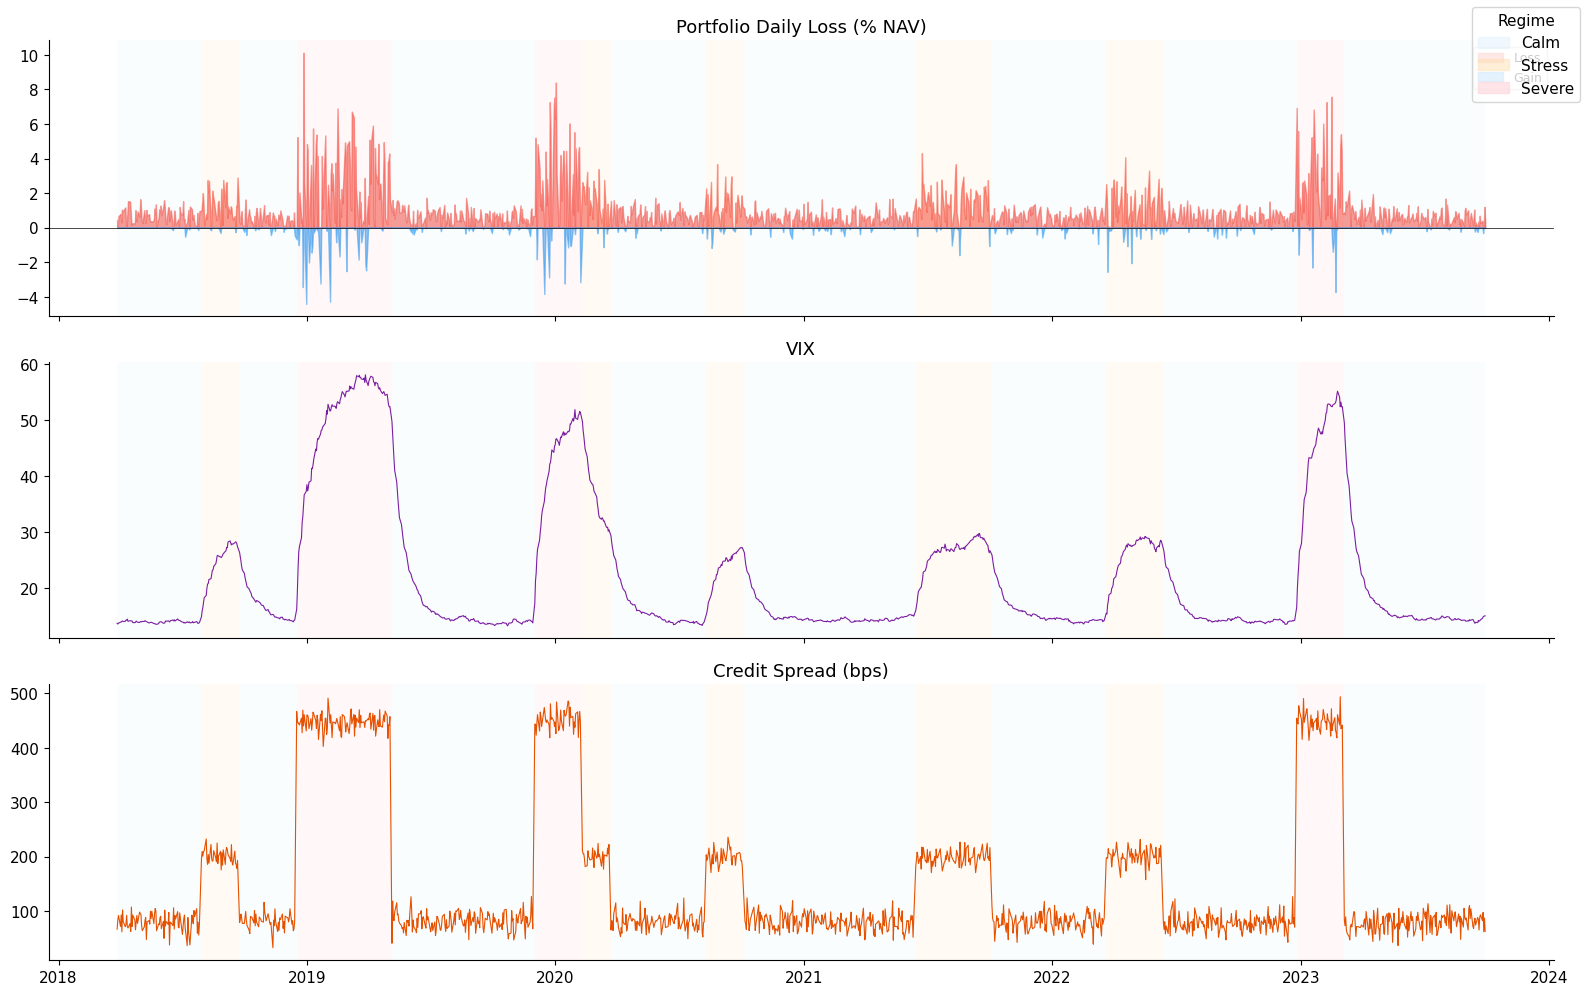

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
regime_colors = {'calm': '#E3F2FD', 'stress': '#FFE0B2', 'severe': '#FFCDD2'}

def shade_regimes_fast(ax, dates_, regime_labels_):
    changes = np.where(np.diff(regime_labels_) != 0)[0] + 1
    edges = np.concatenate([[0], changes, [len(regime_labels_)]])
    for i in range(len(edges) - 1):
        s, e = edges[i], edges[i+1]
        ax.axvspan(dates_[s], dates_[min(e, len(dates_)-1)],
                   alpha=0.15, color=regime_colors.get(regime_names[regime_labels_[s]], 'white'), lw=0)

regime_arr = df['regime'].values
dates_arr  = df.index

axes[0].fill_between(dates_arr, df['portfolio_loss'].clip(lower=0), 0,
                     color=PALETTE['stress'], alpha=0.6, label='Loss')
axes[0].fill_between(dates_arr, df['portfolio_loss'].clip(upper=0), 0,
                     color=PALETTE['calm'], alpha=0.6, label='Gain')
shade_regimes_fast(axes[0], dates_arr, regime_arr)
axes[0].set_title('Portfolio Daily Loss (% NAV)')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].legend(loc='upper right', fontsize=9)

axes[1].plot(dates_arr, df['vix'], color='#7B1FA2', lw=0.8)
shade_regimes_fast(axes[1], dates_arr, regime_arr)
axes[1].set_title('VIX')

axes[2].plot(dates_arr, df['credit_spread'], color='#E65100', lw=0.8)
shade_regimes_fast(axes[2], dates_arr, regime_arr)
axes[2].set_title('Credit Spread (bps)')

patches = [mpatches.Patch(color=c, alpha=0.5, label=r.capitalize())
           for r, c in regime_colors.items()]
fig.legend(handles=patches, loc='upper right', title='Regime')
plt.tight_layout()
plt.savefig('1_regime_overview.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2 — Data Preparation & Temporal Splits

```
┌──────────────────┬──────────────────┬──────────────────┐
│  TRAIN (60%)     │  CALIBRATE (20%) │  TEST (20%)      │
│  Base model fit  │  Conformity      │  Evaluation      │
│                  │  scores          │  + backtesting   │
└──────────────────┴──────────────────┴──────────────────┘
```

In [ ]:
FEATURE_COLS = [
    'vix_lag1', 'vix_lag5',
    'gdp_growth_lag1', 'gdp_growth_lag5',
    'unemployment_lag1', 'unemployment_lag5',
    'credit_spread_lag1', 'credit_spread_lag5',
    'rate_10y_lag1', 'rate_10y_lag5',
    'equity_ret_lag1', 'equity_ret_lag5',
    'eq_vol_21d', 'eq_vol_63d', 'eq_mom_10d',
]

X_all  = df[FEATURE_COLS].values
y_all  = df['portfolio_loss'].values
reg_all = df['regime'].values
dt_all  = df.index

n       = len(X_all)
n_train = int(0.60 * n)
n_cal   = int(0.20 * n)
n_test  = n - n_train - n_cal

X_train, y_train = X_all[:n_train],          y_all[:n_train]
X_cal,   y_cal   = X_all[n_train:n_train+n_cal], y_all[n_train:n_train+n_cal]
X_test,  y_test  = X_all[n_train+n_cal:],    y_all[n_train+n_cal:]

reg_cal  = reg_all[n_train:n_train+n_cal]
reg_test = reg_all[n_train+n_cal:]
dt_test  = dt_all[n_train+n_cal:]

print(f'Train:       {n_train:,} days  {dt_all[0].date()} -> {dt_all[n_train-1].date()}')
print(f'Calibration: {n_cal:,} days  {dt_all[n_train].date()} -> {dt_all[n_train+n_cal-1].date()}')
print(f'Test:        {n_test:,} days  {dt_test[0].date()} -> {dt_test[-1].date()}')
print(f'Test regimes: {pd.Series(reg_test).map(regime_names).value_counts().to_dict()}')

Train:       862 days  2018-03-28 -> 2021-07-15
Calibration: 287 days  2021-07-16 -> 2022-08-22
Test:        289 days  2022-08-23 -> 2023-09-29
Test regimes: {'calm': 239, 'severe': 50}


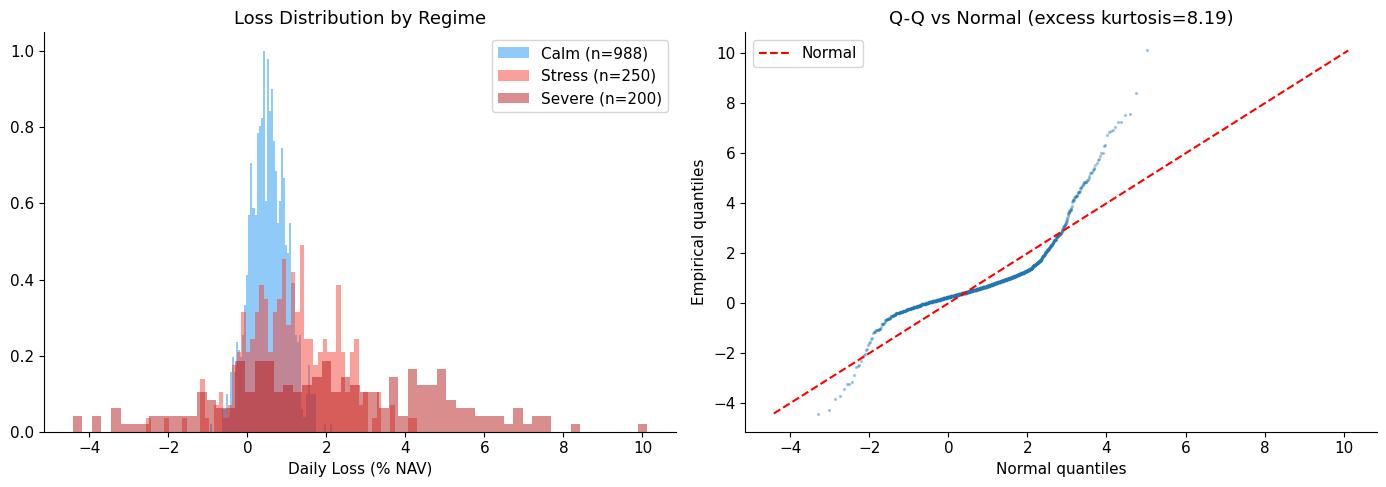

Fat tails confirm non-normality => parametric VaR understates tail risk


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for reg_id, label in regime_names.items():
    data  = y_all[reg_all == reg_id]
    color = [PALETTE['calm'], PALETTE['stress'], '#B71C1C'][reg_id]
    axes[0].hist(data, bins=60, alpha=0.5, density=True,
                 label=f'{label.capitalize()} (n={len(data):,})', color=color)
axes[0].set_title('Loss Distribution by Regime')
axes[0].set_xlabel('Daily Loss (% NAV)')
axes[0].legend()

sorted_y = np.sort(y_all)
q_idx    = np.arange(1, len(sorted_y)+1) / (len(sorted_y) + 1)
norm_q   = stats.norm.ppf(q_idx, loc=y_all.mean(), scale=y_all.std())
axes[1].scatter(norm_q, sorted_y, s=2, alpha=0.3)
lim = [min(norm_q.min(), sorted_y.min()), max(norm_q.max(), sorted_y.max())]
axes[1].plot(lim, lim, 'r--', lw=1.5, label='Normal')
axes[1].set_title(f'Q-Q vs Normal (excess kurtosis={stats.kurtosis(y_all):.2f})')
axes[1].set_xlabel('Normal quantiles')
axes[1].set_ylabel('Empirical quantiles')
axes[1].legend()

plt.tight_layout()
plt.savefig('2_loss_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fat tails confirm non-normality => parametric VaR understates tail risk')

---
## Section 3 — Base Model Training

We train two base models:
1. **Ridge** — linear, interpretable baseline (with StandardScaler)
2. **HistGradientBoostingRegressor** — nonlinear, handles macro-loss interactions

A quantile variant of HistGBM (`loss='quantile'`) serves as the foundation for CQR.

In [ ]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_cal_sc   = scaler.transform(X_cal)
X_test_sc  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
ridge_rmse = np.sqrt(np.mean((y_test - ridge.predict(X_test_sc))**2))
print(f'Ridge RMSE: {ridge_rmse:.4f}')

hgbm = HistGradientBoostingRegressor(
    max_iter=300, max_depth=4, learning_rate=0.05,
    min_samples_leaf=20, random_state=SEED
)
hgbm.fit(X_train, y_train)
hgbm_rmse = np.sqrt(np.mean((y_test - hgbm.predict(X_test))**2))
print(f'HistGBM RMSE: {hgbm_rmse:.4f}')

ALPHA    = 0.10
q_lo, q_hi = ALPHA / 2, 1 - ALPHA / 2

hgbm_q = HistGradientBoostingRegressor(
    loss='quantile', quantile=0.5,
    max_iter=300, max_depth=4, learning_rate=0.05,
    min_samples_leaf=20, random_state=SEED
)
hgbm_q.fit(X_train, y_train)
print(f'HistGBM quantile (median) pinball loss: '
      f'{mean_pinball_loss(y_test, hgbm_q.predict(X_test), alpha=0.5):.4f}')

Ridge RMSE: 1.1223
HistGBM RMSE: 1.2933
HistGBM quantile (median) pinball loss: 0.3498


Computing permutation feature importances (this takes ~30s)...


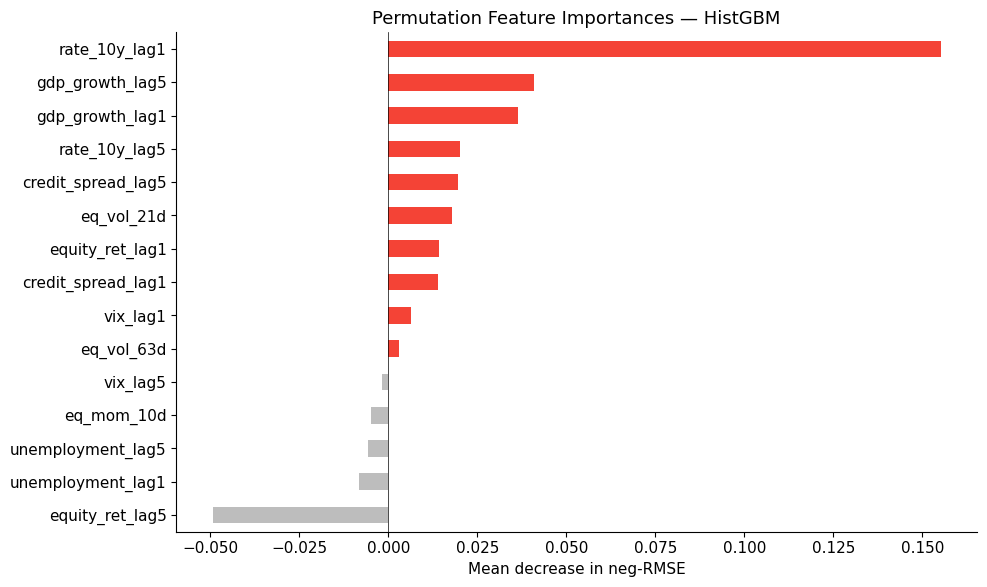

In [ ]:
print('Computing permutation feature importances (this takes ~30s)...')
perm = permutation_importance(
    hgbm, X_test, y_test,
    n_repeats=10, random_state=SEED, scoring='neg_root_mean_squared_error'
)
imp_df = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#F44336' if v > 0 else '#BDBDBD' for v in imp_df.values]
imp_df.plot.barh(ax=ax, color=colors)
ax.set_title('Permutation Feature Importances — HistGBM')
ax.set_xlabel('Mean decrease in neg-RMSE')
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.savefig('3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

### Section 3b — SHAP Analysis (Model Transparency)

`shap.TreeExplainer` provides **exact** Shapley values for gradient-boosted trees — no approximation needed.  
These values quantify each feature's marginal contribution to every individual prediction, enabling:

- **Global importance** (mean |SHAP|) — a more faithful ranking than split-gain or permutation importance alone  
- **Beeswarm plot** — shows *direction* of effect (positive SHAP → higher predicted loss) and *heterogeneity* across observations  
- **Regulatory transparency** — SHAP outputs can be embedded in SR 11-7 model documentation as per-prediction attribution

Computing SHAP values via TreeExplainer (exact, ~10 s)...
SHAP matrix shape: (289, 15)


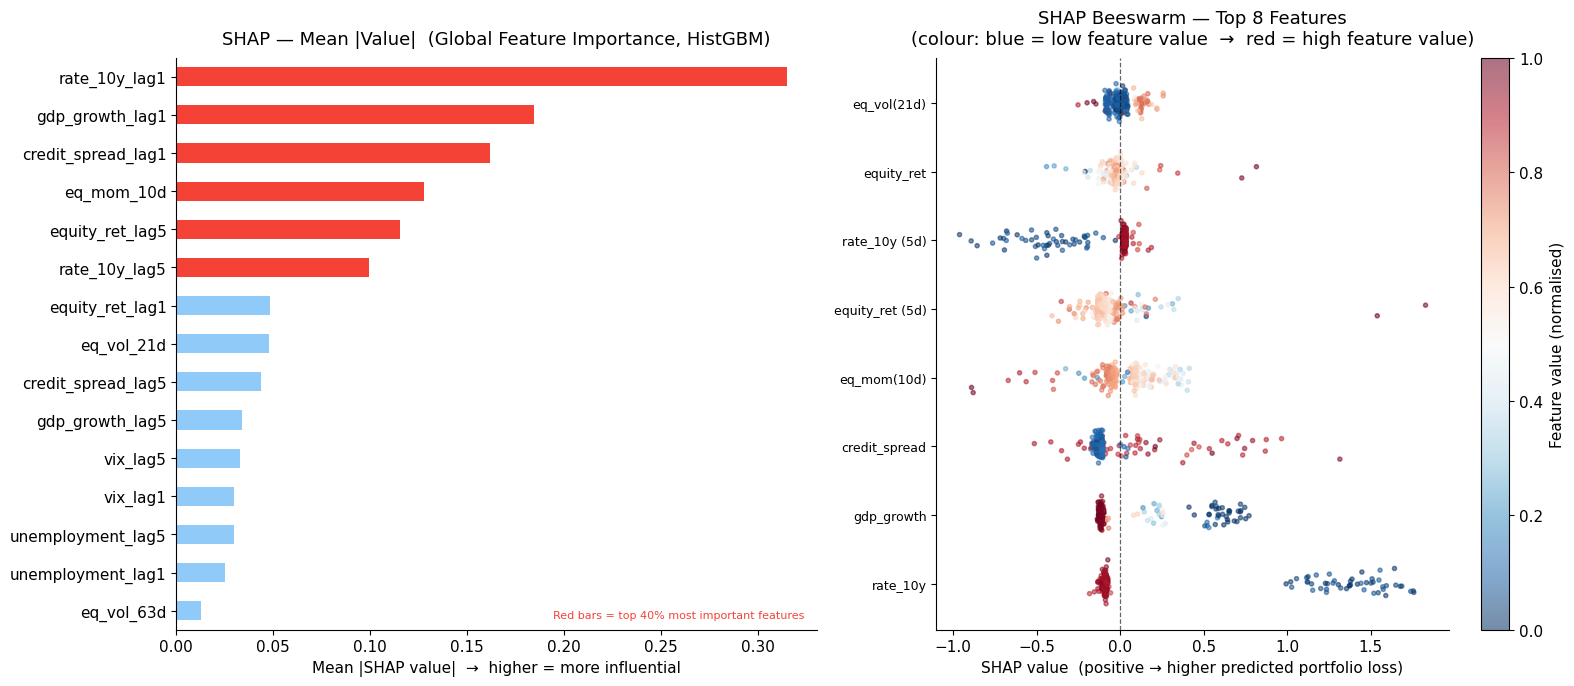


Key takeaways:
  rate_10y_lag1              mean|SHAP| = 0.3148
  gdp_growth_lag1            mean|SHAP| = 0.1846
  credit_spread_lag1         mean|SHAP| = 0.1618


In [ ]:
# ── SHAP Analysis ─────────────────────────────────────────────────────────────
# TreeExplainer is exact (no sampling approximation) for gradient-boosted trees.
# We explain the HistGBM point predictions that underpin SCP, CQR, Rolling CP, and Mondrian CP.
print('Computing SHAP values via TreeExplainer (exact, ~10 s)...')
explainer   = shap.TreeExplainer(hgbm)
shap_values = explainer.shap_values(X_test)   # shape: (n_test, n_features)
print(f'SHAP matrix shape: {shap_values.shape}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left panel: Mean |SHAP| — global importance ──────────────────────────────
mean_abs  = np.abs(shap_values).mean(axis=0)
shap_imp  = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=True)
bar_colors = ['#F44336' if v >= shap_imp.quantile(0.60) else '#90CAF9'
              for v in shap_imp.values]
shap_imp.plot.barh(ax=axes[0], color=bar_colors)
axes[0].set_title('SHAP — Mean |Value|  (Global Feature Importance, HistGBM)', pad=10)
axes[0].set_xlabel('Mean |SHAP value|  →  higher = more influential')
axes[0].axvline(0, color='k', lw=0.5)
axes[0].text(0.98, 0.02, 'Red bars = top 40% most important features',
             transform=axes[0].transAxes, ha='right', fontsize=8, color='#F44336')

# ── Right panel: Beeswarm scatter — top-8 features ───────────────────────────
top8 = shap_imp.sort_values(ascending=False).head(8).index.tolist()
np.random.seed(SEED)
for rank, feat in enumerate(top8):
    fidx  = FEATURE_COLS.index(feat)
    sv    = shap_values[:, fidx]
    fv    = X_test[:, fidx]
    fv_n  = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)   # normalise 0→1
    jitter = np.random.randn(len(sv)) * 0.09
    sc = axes[1].scatter(sv, rank + jitter, c=fv_n,
                         cmap='RdBu_r', s=9, alpha=0.55, vmin=0, vmax=1)

def _shorten(name):
    return (name.replace('_lag1', '').replace('_lag5', ' (5d)')
                .replace('eq_vol_21d', 'eq_vol(21d)').replace('eq_vol_63d', 'eq_vol(63d)')
                .replace('eq_mom_10d', 'eq_mom(10d)'))

axes[1].set_yticks(range(8))
axes[1].set_yticklabels([_shorten(f) for f in top8], fontsize=9)
axes[1].axvline(0, color='k', lw=0.9, ls='--', alpha=0.6)
axes[1].set_xlabel('SHAP value  (positive → higher predicted portfolio loss)')
axes[1].set_title('SHAP Beeswarm — Top 8 Features\n'
                  '(colour: blue = low feature value  →  red = high feature value)', pad=10)
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Feature value (normalised)')

plt.tight_layout()
plt.savefig('3b_shap_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nKey takeaways:')
top3 = shap_imp.sort_values(ascending=False).head(3)
for feat, val in top3.items():
    print(f'  {feat:<25}  mean|SHAP| = {val:.4f}')

---
## Section 4 — Conformal Prediction Methods

| Method | Key Idea | MAPIE 1.3 Class |
|---|---|---|
| **SCP** | Symmetric conformity scores from residuals | `SplitConformalRegressor` |
| **CQR** | Conforms quantile-regressor residuals, asymmetric | `ConformalizedQuantileRegressor` |
| **ACI** | Online alpha-adjustment for distributional shift | `TimeSeriesRegressor(method='aci')` |
| **Rolling CP** | Sliding calibration window | Custom (numpy) |

> **MAPIE 1.3 API note:**  
> `predict_interval()` returns `(point_preds, intervals)` where `intervals.shape = (n, 2, 1)`;  
> use `intervals[:, 0, 0]` for lower bounds and `intervals[:, 1, 0]` for upper bounds.

In [ ]:
CONFIDENCE = 0.90

scp = SplitConformalRegressor(
    HistGradientBoostingRegressor(
        max_iter=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=20, random_state=SEED
    ),
    confidence_level=CONFIDENCE,
    prefit=False,
)
scp.fit(X_train, y_train)
scp.conformalize(X_cal, y_cal)

scp_pts, scp_ints = scp.predict_interval(X_test)
scp_lo  = scp_ints[:, 0, 0]
scp_hi  = scp_ints[:, 1, 0]
scp_covered = (y_test >= scp_lo) & (y_test <= scp_hi)
scp_width   = scp_hi - scp_lo

print('Split Conformal Prediction (SCP)')
print(f'  Coverage:     {scp_covered.mean():.3%}  (target {CONFIDENCE:.0%})')
print(f'  Mean width:   {scp_width.mean():.4f}')
print(f'  Median width: {np.median(scp_width):.4f}')

Split Conformal Prediction (SCP)
  Coverage:     88.581%  (target 90%)
  Mean width:   3.1051
  Median width: 3.1051


In [ ]:
cqr = ConformalizedQuantileRegressor(
    HistGradientBoostingRegressor(
        loss='quantile', quantile=0.5,
        max_iter=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=20, random_state=SEED
    ),
    confidence_level=CONFIDENCE,
    prefit=False,
)
cqr.fit(X_train, y_train)
cqr.conformalize(X_cal, y_cal)

cqr_pts, cqr_ints = cqr.predict_interval(X_test)
cqr_lo  = cqr_ints[:, 0, 0]
cqr_hi  = cqr_ints[:, 1, 0]
cqr_covered = (y_test >= cqr_lo) & (y_test <= cqr_hi)
cqr_width   = cqr_hi - cqr_lo

print('Conformalized Quantile Regression (CQR)')
print(f'  Coverage:        {cqr_covered.mean():.3%}')
print(f'  Mean width:      {cqr_width.mean():.4f}')
print(f'  Width (calm):    {cqr_width[reg_test==0].mean():.4f}')
print(f'  Width (stress):  {cqr_width[reg_test==1].mean():.4f}')
print(f'  Width (severe):  {cqr_width[reg_test==2].mean():.4f}')

Conformalized Quantile Regression (CQR)
  Coverage:        93.772%
  Mean width:      2.9787
  Width (calm):    1.8984
  Width (stress):  nan
  Width (severe):  8.1424


In [ ]:
# ACI: uses method='aci' which supports adapt_conformal_inference
# Fit on train+cal combined; then do online update per test day
X_tc = np.vstack([X_train, X_cal])
y_tc = np.concatenate([y_train, y_cal])

aci_model = TimeSeriesRegressor(
    HistGradientBoostingRegressor(
        max_iter=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=20, random_state=SEED
    ),
    method='aci',
    cv=TimeSeriesSplit(n_splits=5),
    agg_function='mean',
)
aci_model.fit(X_tc, y_tc)

ACI_GAMMA = 0.05
aci_lo_list, aci_hi_list = [], []

for t in range(len(X_test)):
    if t > 0:
        aci_model.adapt_conformal_inference(
            X_test[t-1:t], y_test[t-1:t],
            gamma=ACI_GAMMA,
            confidence_level=CONFIDENCE,
            ensemble=True,
        )
    pts_t, ints_t = aci_model.predict(
        X_test[t:t+1], confidence_level=CONFIDENCE,
        ensemble=True, allow_infinite_bounds=True
    )
    aci_lo_list.append(float(ints_t[0, 0, 0]))
    aci_hi_list.append(float(ints_t[0, 1, 0]))

aci_lo = np.array(aci_lo_list)
aci_hi = np.array(aci_hi_list)
aci_covered = (y_test >= aci_lo) & (y_test <= aci_hi)
aci_width   = aci_hi - aci_lo

print('Adaptive Conformal Inference (ACI)')
print(f'  Coverage:        {aci_covered.mean():.3%}')
print(f'  Mean width:      {aci_width.mean():.4f}')
print(f'  Width (calm):    {aci_width[reg_test==0].mean():.4f}')
print(f'  Width (stress):  {aci_width[reg_test==1].mean():.4f}')
print(f'  Width (severe):  {aci_width[reg_test==2].mean():.4f}')

/usr/local/lib/python3.12/dist-packages/mapie/utils.py:683: UserWarning: WARNING: at least one point of training set belongs to every resamplings.
Increase the number of resamplings
  warnings.warn(


Adaptive Conformal Inference (ACI)
  Coverage:        90.657%
  Mean width:      inf
  Width (calm):    inf
  Width (stress):  nan
  Width (severe):  inf


In [ ]:
ROLLING_W = 60
roll_base = HistGradientBoostingRegressor(
    max_iter=300, max_depth=4, learning_rate=0.05,
    min_samples_leaf=20, random_state=SEED
)
roll_base.fit(X_train, y_train)

cal_scores_roll = np.abs(y_cal - roll_base.predict(X_cal))
score_buf = list(cal_scores_roll[-ROLLING_W:])

roll_lo_list, roll_hi_list = [], []
for t in range(len(X_test)):
    pt = roll_base.predict(X_test[t:t+1])[0]
    q  = np.quantile(score_buf, CONFIDENCE)
    roll_lo_list.append(pt - q)
    roll_hi_list.append(pt + q)
    score_buf.append(abs(y_test[t] - pt))
    if len(score_buf) > ROLLING_W:
        score_buf.pop(0)

roll_lo = np.array(roll_lo_list)
roll_hi = np.array(roll_hi_list)
roll_covered = (y_test >= roll_lo) & (y_test <= roll_hi)
roll_width   = roll_hi - roll_lo

print(f'Rolling-Window CP (W={ROLLING_W}d)')
print(f'  Coverage:        {roll_covered.mean():.3%}')
print(f'  Mean width:      {roll_width.mean():.4f}')
print(f'  Width (calm):    {roll_width[reg_test==0].mean():.4f}')
print(f'  Width (stress):  {roll_width[reg_test==1].mean():.4f}')
print(f'  Width (severe):  {roll_width[reg_test==2].mean():.4f}')

Rolling-Window CP (W=60d)
  Coverage:        87.197%
  Mean width:      3.4543
  Width (calm):    2.9233
  Width (stress):  nan
  Width (severe):  5.9926


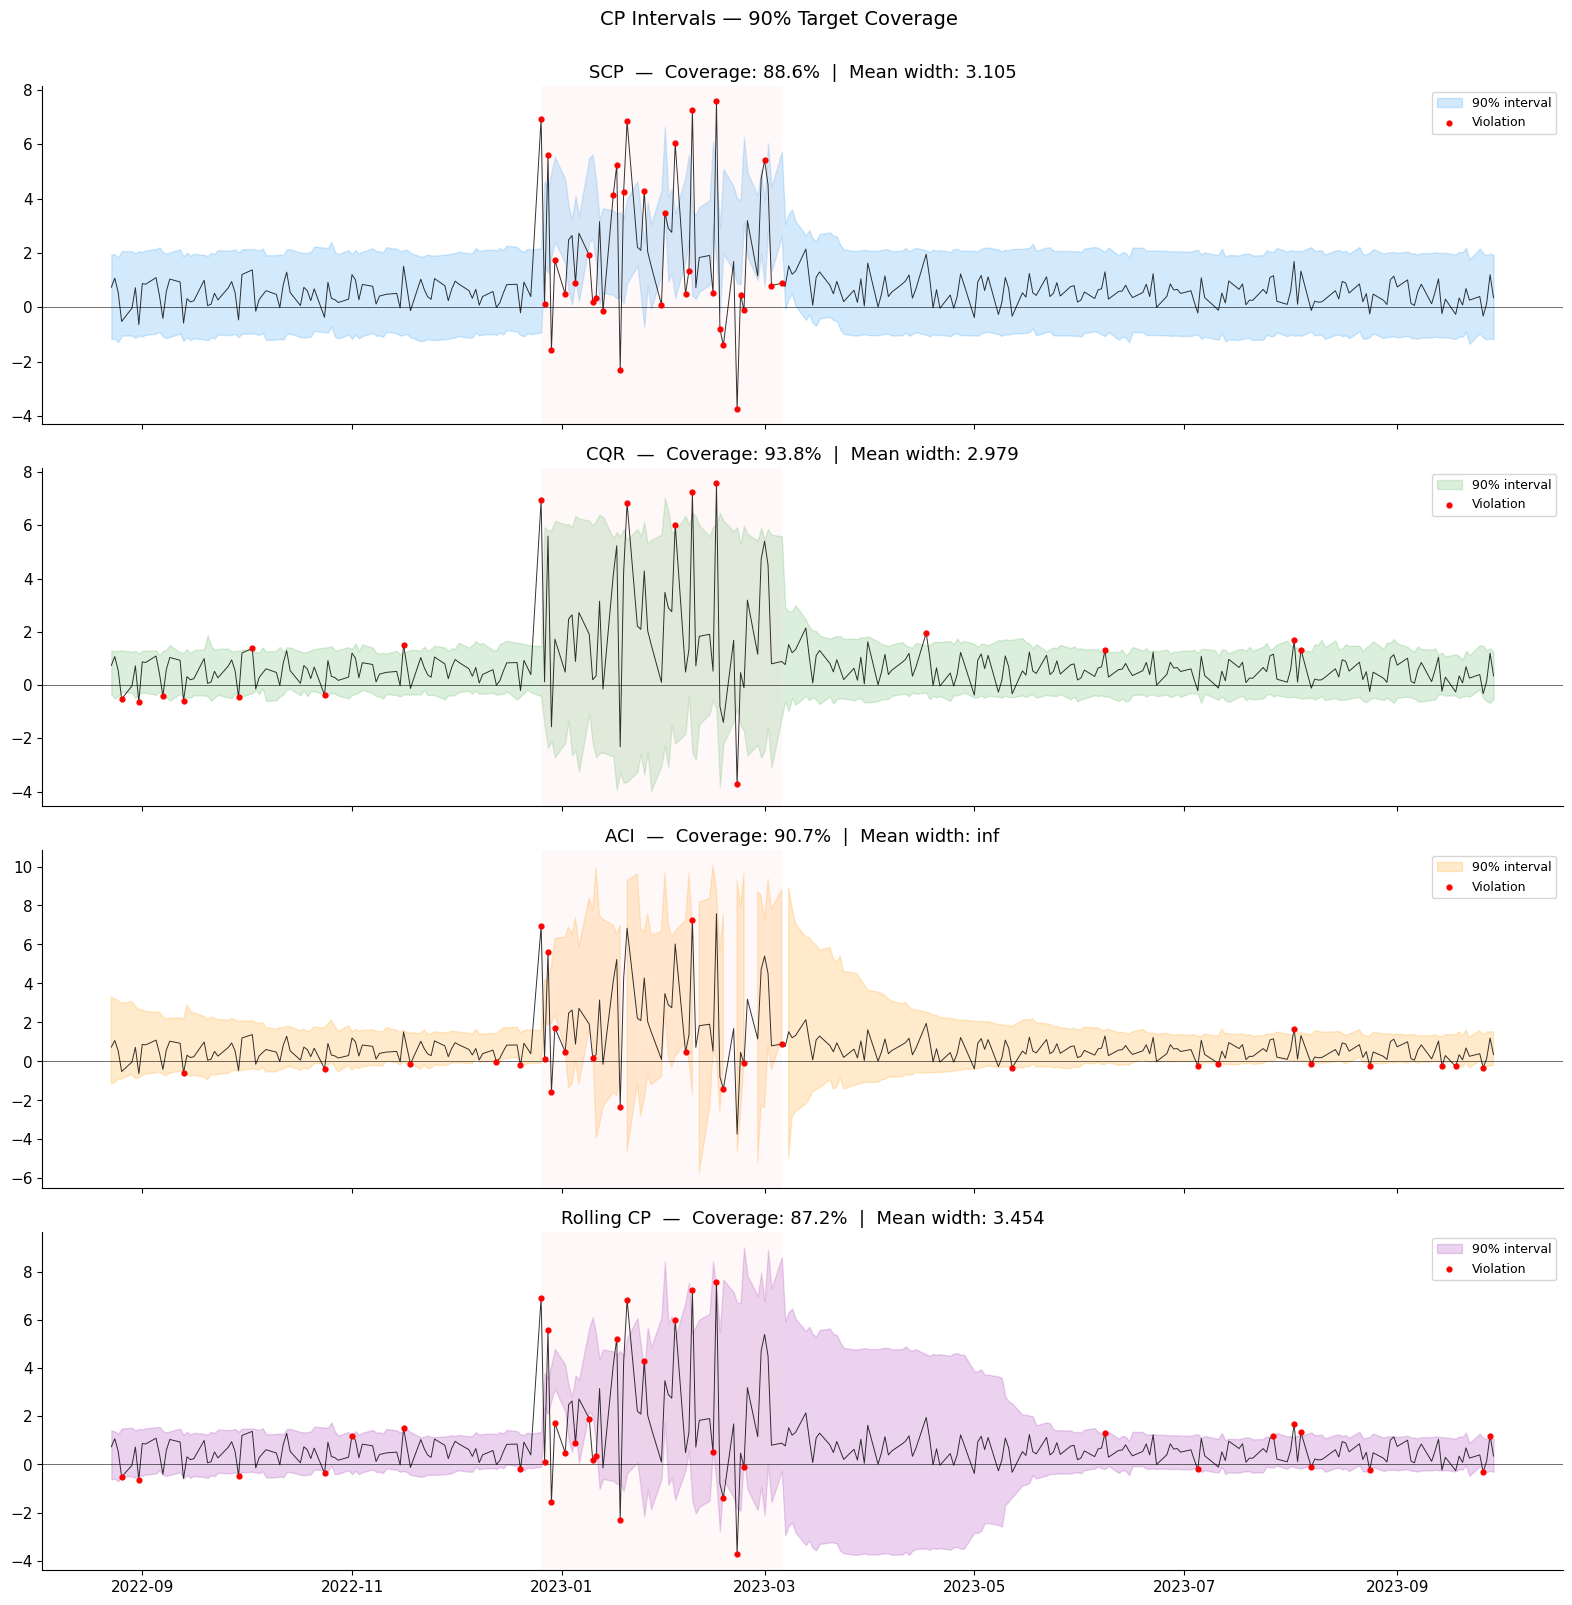

In [ ]:
plot_n = min(300, len(X_test))
dt_plot = dt_test[:plot_n]
y_plot  = y_test[:plot_n]
reg_plot = reg_test[:plot_n]

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
methods_plot = [
    ('SCP',          scp_lo[:plot_n],  scp_hi[:plot_n],  '#2196F3'),
    ('CQR',          cqr_lo[:plot_n],  cqr_hi[:plot_n],  '#4CAF50'),
    ('ACI',          aci_lo[:plot_n],  aci_hi[:plot_n],  '#FF9800'),
    ('Rolling CP',   roll_lo[:plot_n], roll_hi[:plot_n], '#9C27B0'),
]

for ax, (name, lo, hi, color) in zip(axes, methods_plot):
    covered_m = (y_plot >= lo) & (y_plot <= hi)
    ax.fill_between(dt_plot, lo, hi, alpha=0.2, color=color, label='90% interval')
    ax.plot(dt_plot, y_plot, color='black', lw=0.7, alpha=0.8)
    ax.scatter(dt_plot[~covered_m], y_plot[~covered_m], color='red', s=12, zorder=5, label='Violation')
    cov_m = covered_m.mean()
    ax.set_title(f'{name}  —  Coverage: {cov_m:.1%}  |  Mean width: {(hi-lo).mean():.3f}')
    ax.axhline(0, color='k', lw=0.4)
    ax.legend(loc='upper right', fontsize=9)
    changes = np.where(np.diff(reg_plot) != 0)[0] + 1
    edges = np.concatenate([[0], changes, [plot_n]])
    for i in range(len(edges)-1):
        s, e = edges[i], min(edges[i+1], plot_n-1)
        if reg_plot[s] >= 1:
            c = '#FFCDD2' if reg_plot[s] == 2 else '#FFE0B2'
            ax.axvspan(dt_plot[s], dt_plot[e], alpha=0.12, color=c, lw=0)

plt.suptitle('CP Intervals — 90% Target Coverage', fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig('4_cp_intervals_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 5 — Stress Regime Adaptation

### Mondrian Conformal Prediction
Mondrian CP calibrates **separately per regime**, delivering *conditional* coverage guarantees:
$$\mathbb{P}(Y \in \hat{C}^k_\alpha \mid \text{regime} = k) \geq 1 - \alpha$$

### Conformal Predictive Distribution (CPD) via crepes
The `WrapRegressor` from crepes generates a full **predictive distribution** (dense quantile grid) enabling Monte Carlo scenario simulation, VaR, and ES — all without parametric assumptions.

In [ ]:
mond_base = HistGradientBoostingRegressor(
    max_iter=300, max_depth=4, learning_rate=0.05,
    min_samples_leaf=20, random_state=SEED
)
mond_base.fit(X_train, y_train)

cal_scores_m = np.abs(y_cal - mond_base.predict(X_cal))

mond_quantiles = {}
for reg_id in [0, 1, 2]:
    mask = reg_cal == reg_id
    if mask.sum() >= 10:
        mond_quantiles[reg_id] = np.quantile(cal_scores_m[mask], CONFIDENCE)
    else:
        mond_quantiles[reg_id] = np.quantile(cal_scores_m, CONFIDENCE)
    print(f'Regime {regime_names[reg_id]:6s}: n_cal={mask.sum():4d}  '
          f'q({CONFIDENCE:.0%})={mond_quantiles[reg_id]:.4f}')

test_pts_m  = mond_base.predict(X_test)
mond_q_vec  = np.array([mond_quantiles[r] for r in reg_test])
mond_lo     = test_pts_m - mond_q_vec
mond_hi     = test_pts_m + mond_q_vec
mond_covered = (y_test >= mond_lo) & (y_test <= mond_hi)
mond_width   = mond_hi - mond_lo

print('\nMondrian CP — Regime-Conditional Coverage')
for reg_id, reg_name in regime_names.items():
    mask = reg_test == reg_id
    if mask.sum() > 0:
        print(f'  {reg_name:6s}: cov={mond_covered[mask].mean():.3%}  '
              f'width={mond_width[mask].mean():.4f}  n={mask.sum()}')
print(f'  Overall:  cov={mond_covered.mean():.3%}')

Regime calm  : n_cal= 171  q(90%)=0.8629
Regime stress: n_cal= 116  q(90%)=2.0157
Regime severe: n_cal=   0  q(90%)=1.4702

Mondrian CP — Regime-Conditional Coverage
  calm  : cov=93.724%  width=1.7258  n=239
  severe: cov=34.000%  width=2.9405  n=50
  Overall:  cov=83.391%


In [ ]:
# CPD: calibrate with cps=True to enable predict_cps
cpd_model = WrapRegressor(
    HistGradientBoostingRegressor(
        max_iter=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=20, random_state=SEED
    )
)
cpd_model.fit(X_train, y_train)
cpd_model.calibrate(X_cal, y_cal, cps=True)

# Dense percentile grid for fan chart and MC approximation
PCTS_DENSE = list(range(1, 100))   # 1st to 99th percentile
FAN_N = 200                         # first 200 test days

cpd_dense = cpd_model.predict_cps(
    X_test[:FAN_N], lower_percentiles=PCTS_DENSE
)  # shape: (FAN_N, 99)
print(f'CPD dense output shape: {cpd_dense.shape}')

print('VaR/ES from CPD for first 5 test days:')
for i in range(5):
    row = cpd_dense[i]
    var95 = row[94]  # 95th percentile (index 94 = 95th in 1..99)
    var99 = row[98]  # 99th percentile
    es95  = row[94:].mean()
    print(f'  Day {i+1}: VaR95={var95:.4f}  VaR99={var99:.4f}  ES95={es95:.4f}  Actual={y_test[i]:.4f}')

CPD dense output shape: (200, 99)
VaR/ES from CPD for first 5 test days:
  Day 1: VaR95=1.8279  VaR99=2.7395  ES95=2.2489  Actual=0.7380
  Day 2: VaR95=1.8303  VaR99=2.7420  ES95=2.2514  Actual=1.0715
  Day 3: VaR95=1.7137  VaR99=2.6254  ES95=2.1348  Actual=0.5450
  Day 4: VaR95=1.9501  VaR99=2.8618  ES95=2.3712  Actual=-0.5207
  Day 5: VaR95=1.9516  VaR99=2.8633  ES95=2.3726  Actual=-0.0305


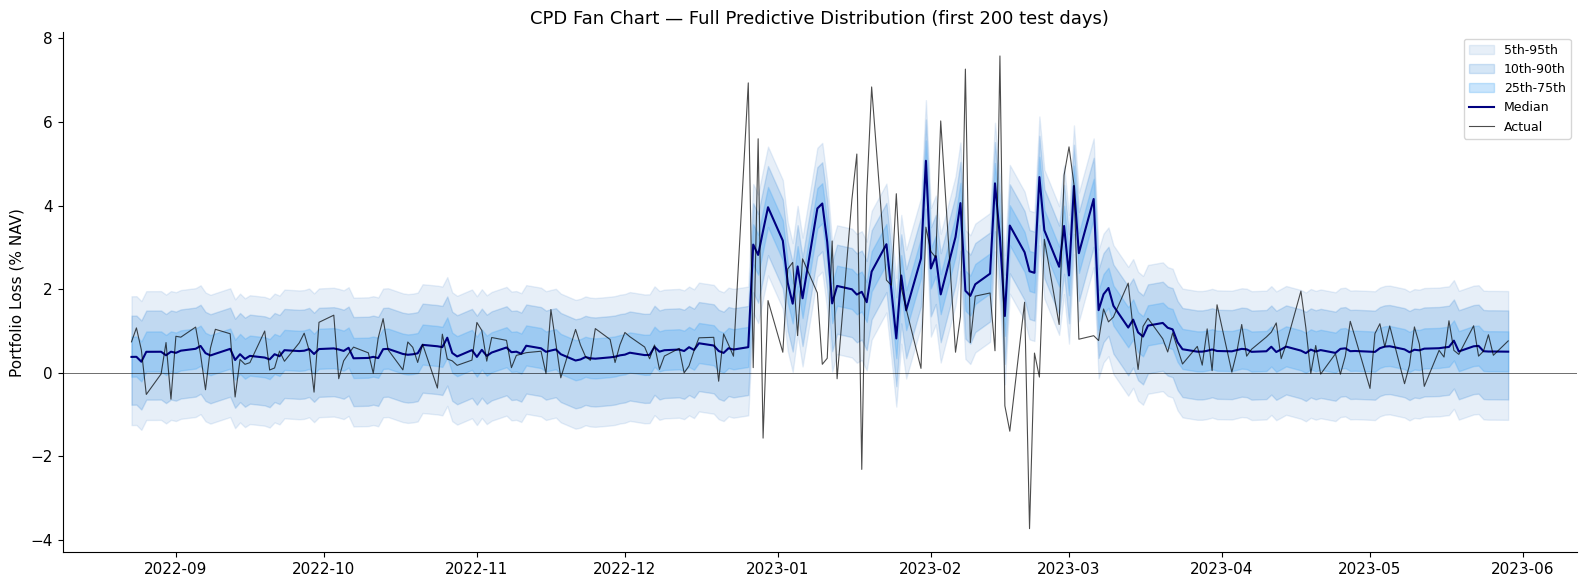

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

fan_pairs = [(4, 94, 0.10), (9, 89, 0.18), (24, 74, 0.28)]
colors_fan = ['#1565C0', '#1976D2', '#42A5F5']
labels_fan = ['5th-95th', '10th-90th', '25th-75th']

for (lo_i, hi_i, alpha_), col, lbl in zip(fan_pairs, colors_fan, labels_fan):
    ax.fill_between(dt_test[:FAN_N],
                    cpd_dense[:, lo_i],
                    cpd_dense[:, hi_i],
                    alpha=alpha_, color=col, label=lbl)

ax.plot(dt_test[:FAN_N], cpd_dense[:, 49], color='navy', lw=1.5, label='Median')
ax.plot(dt_test[:FAN_N], y_test[:FAN_N], color='black', lw=0.8, alpha=0.7, label='Actual')
ax.set_title('CPD Fan Chart — Full Predictive Distribution (first 200 test days)')
ax.set_ylabel('Portfolio Loss (% NAV)')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0, color='k', lw=0.4)
plt.tight_layout()
plt.savefig('5_cpd_fan_chart.png', dpi=120, bbox_inches='tight')
plt.show()

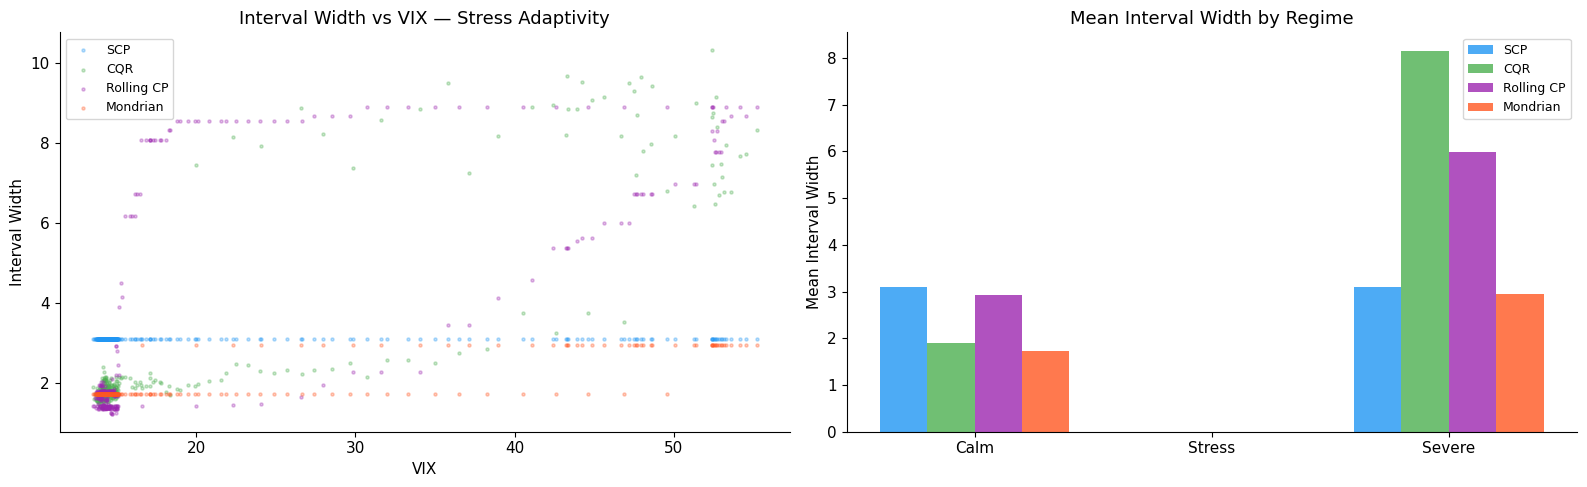

In [ ]:
vix_test = df['vix'].values[n_train+n_cal:]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

methods_w = [
    ('SCP',         scp_width,   '#2196F3'),
    ('CQR',         cqr_width,   '#4CAF50'),
    ('Rolling CP',  roll_width,  '#9C27B0'),
    ('Mondrian',    mond_width,  '#FF5722'),
]

for name, width, color in methods_w:
    axes[0].scatter(vix_test, width, s=5, alpha=0.3, color=color, label=name)
axes[0].set_xlabel('VIX')
axes[0].set_ylabel('Interval Width')
axes[0].set_title('Interval Width vs VIX — Stress Adaptivity')
axes[0].legend(fontsize=9)

x_bar = np.arange(3)
bw    = 0.2
for i, (name, width, color) in enumerate(methods_w):
    means = [width[reg_test==r].mean() for r in [0, 1, 2]]
    axes[1].bar(x_bar + i*bw, means, bw, label=name, color=color, alpha=0.8)
axes[1].set_xticks(x_bar + 1.5*bw)
axes[1].set_xticklabels(['Calm', 'Stress', 'Severe'])
axes[1].set_ylabel('Mean Interval Width')
axes[1].set_title('Mean Interval Width by Regime')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('5_width_by_regime.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 6 — Evaluation & Regulatory Backtesting

| Metric | Formula / Description | Regulatory Use |
|---|---|---|
| **Empirical coverage** | $\hat{p} = T^{-1}\sum_t \mathbf{1}[Y_t \in C_t]$ | Primary CP guarantee |
| **Winkler score** | width + exceedance penalty | Interval quality |
| **CRPS** | Proper scoring rule (Gaussian approx) | Distributional evaluation |
| **Kupiec POF** | $LR = -2\log\frac{L_0}{L_1} \sim \chi^2_1$ | Basel VaR test |
| **Christoffersen CC** | Independence of violation sequence | Basel traffic-light |

In [ ]:
def winkler_score(y, lo, hi, alpha=0.10):
    width = hi - lo
    pen = np.where(y < lo, 2/alpha*(lo-y), np.where(y > hi, 2/alpha*(y-hi), 0))
    return float(np.mean(width + pen))

def crps_gauss(y, mu, sigma):
    z = (y - mu) / (sigma + 1e-8)
    s = sigma * (z*(2*stats.norm.cdf(z)-1) + 2*stats.norm.pdf(z) - 1/np.sqrt(np.pi))
    return float(np.mean(s))

def kupiec_pof(y, var_hi, alpha=0.10):
    T = len(y)
    x = int(np.sum(y > var_hi))
    if x == 0 or x == T:
        return float('nan'), float('nan'), x, alpha*T
    ph = x / T
    lr = -2*(np.log((1-alpha)**(T-x)*alpha**x)
             - np.log((1-ph)**(T-x)*ph**x))
    return float(lr), float(1 - stats.chi2.cdf(lr, df=1)), x, alpha*T

def christoffersen_cc(y, var_hi):
    hits = (y > var_hi).astype(int)
    n00 = ((hits[:-1]==0)&(hits[1:]==0)).sum()
    n01 = ((hits[:-1]==0)&(hits[1:]==1)).sum()
    n10 = ((hits[:-1]==1)&(hits[1:]==0)).sum()
    n11 = ((hits[:-1]==1)&(hits[1:]==1)).sum()
    pi01 = n01/(n00+n01+1e-9)
    pi11 = n11/(n10+n11+1e-9)
    pi   = (n01+n11)/(n00+n01+n10+n11+1e-9)
    def sl(x): return np.log(max(x, 1e-12))
    lr_ind = -2*(
        (n00+n10)*sl(1-pi)+(n01+n11)*sl(pi)
        -(n00*sl(1-pi01)+n01*sl(pi01)+n10*sl(1-pi11)+n11*sl(pi11))
    )
    return float(lr_ind), float(1-stats.chi2.cdf(abs(lr_ind), df=1))

print('Metric functions defined.')

Metric functions defined.


In [ ]:
ALL_METHODS = [
    ('SCP',         scp_lo,  scp_hi,  scp_covered),
    ('CQR',         cqr_lo,  cqr_hi,  cqr_covered),
    ('ACI',         aci_lo,  aci_hi,  aci_covered),
    ('Rolling CP',  roll_lo, roll_hi, roll_covered),
    ('Mondrian CP', mond_lo, mond_hi, mond_covered),
]

rows = []
for name, lo, hi, cov_arr in ALL_METHODS:
    cov   = cov_arr.mean()
    width = float(np.mean(hi - lo))
    wink  = winkler_score(y_test, lo, hi, alpha=1-CONFIDENCE)
    mid   = (lo + hi) / 2
    sig   = (hi - lo) / (2 * stats.norm.ppf(0.5 + CONFIDENCE/2))
    crps  = crps_gauss(y_test, mid, sig)
    lr_k, pv_k, n_viol, n_exp = kupiec_pof(y_test, hi, alpha=1-CONFIDENCE)
    _, pv_cc = christoffersen_cc(y_test, hi)
    rows.append({
        'Method':         name,
        'Coverage':       f'{cov:.3%}',
        'Gap vs target':  f'{cov-CONFIDENCE:+.3%}',
        'Mean Width':     f'{width:.4f}',
        'Winkler':        f'{wink:.4f}',
        'CRPS':           f'{crps:.4f}',
        'Violations':     f'{n_viol}/{len(y_test)}',
        'Expected viol.': f'{n_exp:.1f}',
        'Kupiec p-val':   f'{pv_k:.4f}' if not np.isnan(pv_k) else 'N/A',
        'CC p-val':       f'{pv_cc:.4f}',
    })

eval_df = pd.DataFrame(rows).set_index('Method')
print('='*100)
print('CONFORMAL PREDICTION EVALUATION SUMMARY')
print('='*100)
print(eval_df.to_string())
print('='*100)
print(f'Kupiec/CC p > 0.05 = PASS (no evidence of miscoverage / violation clustering)')

CONFORMAL PREDICTION EVALUATION SUMMARY
            Coverage Gap vs target Mean Width Winkler    CRPS Violations Expected viol. Kupiec p-val CC p-val
Method                                                                                                       
SCP          88.581%       -1.419%     3.1051  7.2138  0.6012     11/289           28.9       0.0001   0.0582
CQR          93.772%       +3.772%     2.9787  3.9735  0.4837     11/289           28.9       0.0001   0.3499
ACI          90.657%       +0.657%        inf     inf     nan      4/289           28.9       0.0000   0.7371
Rolling CP   87.197%       -2.803%     3.4543  5.7071  0.5880     15/289           28.9       0.0029   0.1991
Mondrian CP  83.391%       -6.609%     1.9360  6.4303  0.5678     17/289           28.9       0.0121   0.3438
Kupiec/CC p > 0.05 = PASS (no evidence of miscoverage / violation clustering)


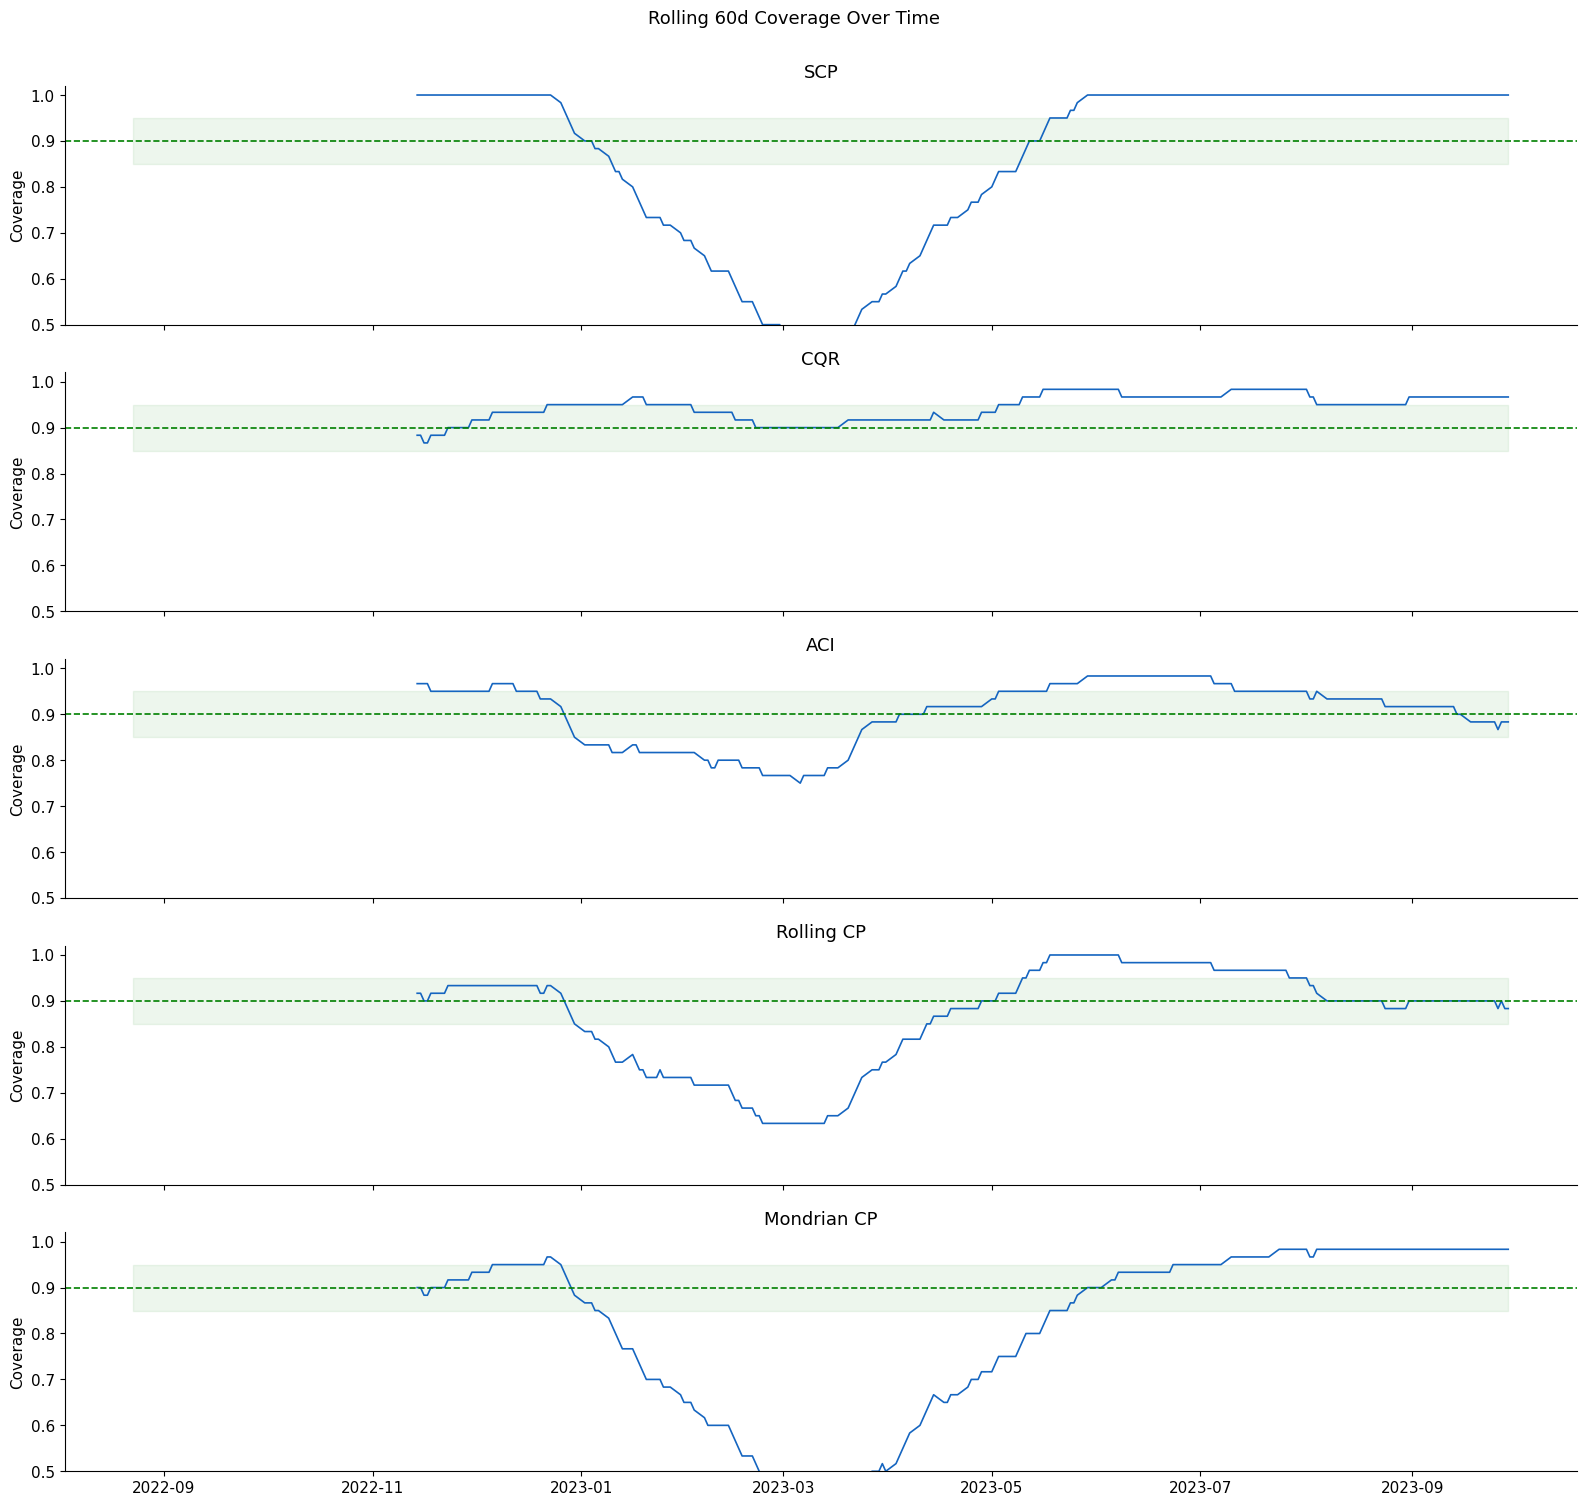

In [ ]:
ROLL_W_EVAL = 60
fig, axes = plt.subplots(len(ALL_METHODS), 1,
                         figsize=(16, 3*len(ALL_METHODS)), sharex=True)

for ax, (name, lo, hi, cov_arr) in zip(axes, ALL_METHODS):
    rc = pd.Series(cov_arr.astype(float), index=dt_test).rolling(ROLL_W_EVAL).mean()
    ax.plot(dt_test, rc.values, color='#1565C0', lw=1.2)
    ax.axhline(CONFIDENCE, color='green', lw=1.2, ls='--', label=f'Target {CONFIDENCE:.0%}')
    ax.fill_between(dt_test, CONFIDENCE-0.05, CONFIDENCE+0.05, alpha=0.07, color='green')
    ax.set_ylim(0.50, 1.02)
    ax.set_title(name)
    ax.set_ylabel('Coverage')

plt.suptitle(f'Rolling {ROLL_W_EVAL}d Coverage Over Time', y=1.002, fontsize=13)
plt.tight_layout()
plt.savefig('6_rolling_coverage.png', dpi=120, bbox_inches='tight')
plt.show()

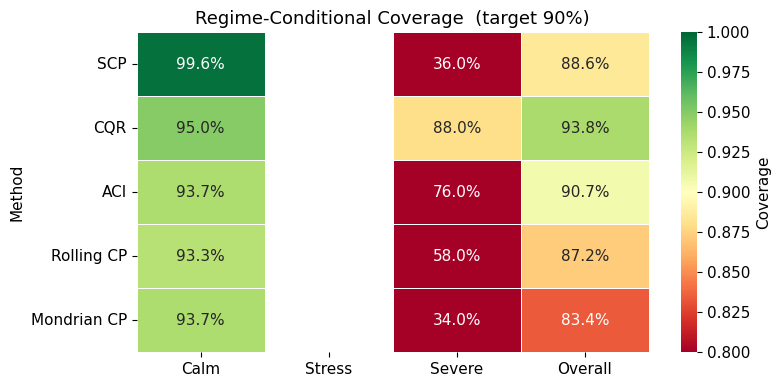

                 Calm  Stress  Severe   Overall
Method                                         
SCP          0.995816     NaN    0.36  0.885813
CQR          0.949791     NaN    0.88  0.937716
ACI          0.937238     NaN    0.76  0.906574
Rolling CP   0.933054     NaN    0.58  0.871972
Mondrian CP  0.937238     NaN    0.34  0.833910


In [ ]:
cov_mat = []
for name, lo, hi, cov_arr in ALL_METHODS:
    row = {'Method': name}
    for rid, rn in regime_names.items():
        m = reg_test == rid
        row[rn.capitalize()] = cov_arr[m].mean() if m.sum() > 0 else np.nan
    row['Overall'] = cov_arr.mean()
    cov_mat.append(row)
cov_df = pd.DataFrame(cov_mat).set_index('Method')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cov_df, annot=True, fmt='.1%', cmap='RdYlGn',
            vmin=0.80, vmax=1.0, center=CONFIDENCE,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Coverage'})
ax.set_title(f'Regime-Conditional Coverage  (target {CONFIDENCE:.0%})')
plt.tight_layout()
plt.savefig('6_coverage_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(cov_df.to_string())

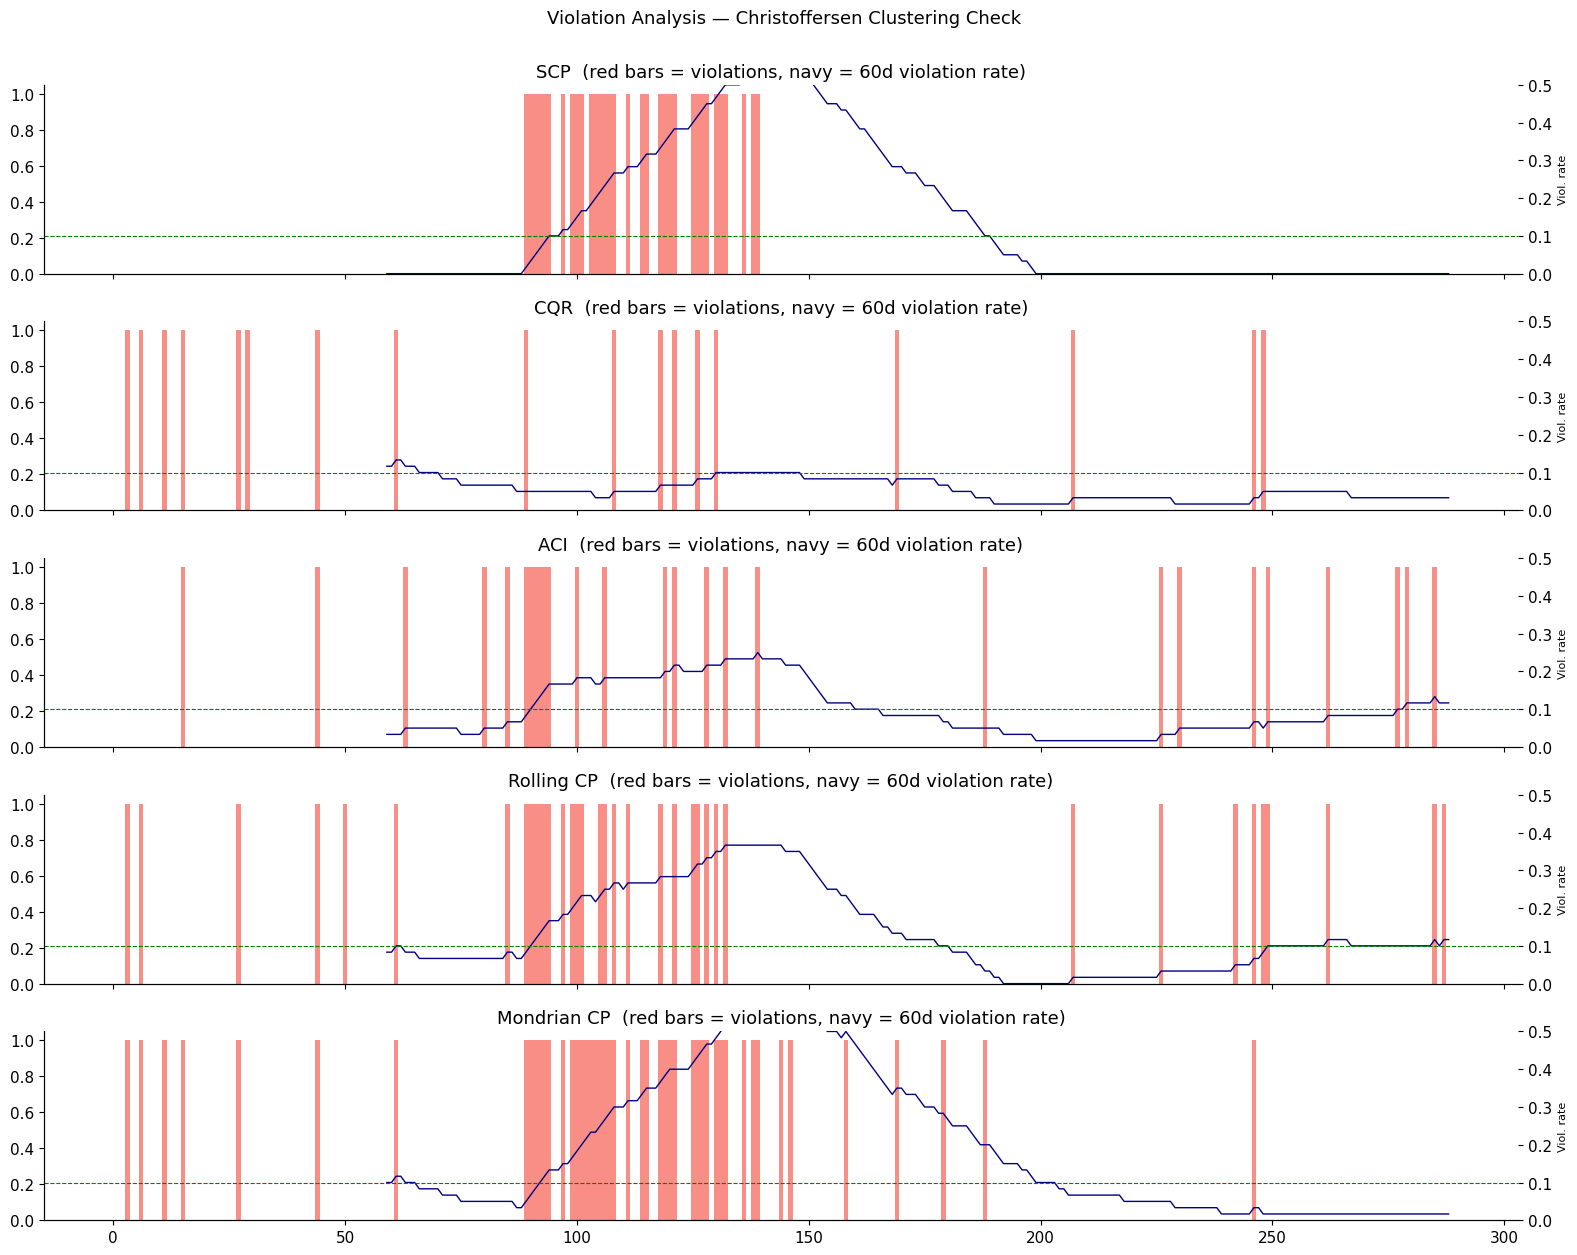

In [ ]:
fig, axes = plt.subplots(len(ALL_METHODS), 1,
                         figsize=(16, 2.5*len(ALL_METHODS)), sharex=True)

for ax, (name, lo, hi, cov_arr) in zip(axes, ALL_METHODS):
    violations = (~cov_arr).astype(float)
    ax.bar(range(len(y_test)), violations, color=PALETTE['stress'], width=1.0, alpha=0.6)
    ax2 = ax.twinx()
    ax2.plot(pd.Series(violations).rolling(60).mean().values, color='navy', lw=1.0)
    ax2.axhline(1-CONFIDENCE, color='green', lw=0.8, ls='--')
    ax2.set_ylim(0, 0.5)
    ax2.set_ylabel('Viol. rate', fontsize=8)
    ax.set_title(f'{name}  (red bars = violations, navy = 60d violation rate)')

plt.suptitle('Violation Analysis — Christoffersen Clustering Check', y=1.002, fontsize=13)
plt.tight_layout()
plt.savefig('6_violation_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 7 — Scenario Analysis & Capital Stress Testing

We apply CP to five regulatory-style scenarios:
- **Baseline**: average recent conditions
- **Adverse**: GDP −2%, credit +200bps, VIX 40 (EBA adverse)
- **Severely Adverse**: GDP −5%, credit +470bps, VIX 72 (DFAST severely adverse)
- **Rate Shock**: 10Y rate at 6.5%, equity sell-off
- **Stagflation**: low growth + high inflation + unemployment

In [ ]:
feat_idx = {f: i for i, f in enumerate(FEATURE_COLS)}
baseline = X_test.mean(axis=0)

def build_scenario(overrides):
    s = baseline.copy()
    for feat, val in overrides.items():
        for suffix in ['_lag1', '_lag5']:
            key = feat + suffix
            if key in feat_idx:
                s[feat_idx[key]] = val
        if feat in feat_idx:
            s[feat_idx[feat]] = val
    return s

scenarios = {
    'Baseline':          baseline,
    'Adverse':           build_scenario({'gdp_growth': -2.0, 'credit_spread': 280,
                                         'vix': 40, 'unemployment': 7.5, 'equity_ret': -1.5}),
    'Severely Adverse':  build_scenario({'gdp_growth': -5.0, 'credit_spread': 550,
                                         'vix': 72, 'unemployment': 12.0, 'equity_ret': -3.5}),
    'Rate Shock':        build_scenario({'rate_10y': 6.5, 'credit_spread': 220,
                                         'vix': 35, 'equity_ret': -0.8}),
    'Stagflation':       build_scenario({'gdp_growth': -1.0, 'unemployment': 9.0,
                                         'rate_10y': 7.0, 'credit_spread': 300, 'vix': 45}),
}
print('Scenarios:', list(scenarios.keys()))

Scenarios: ['Baseline', 'Adverse', 'Severely Adverse', 'Rate Shock', 'Stagflation']


In [ ]:
scen_results = {}

for scen_name, feat_vec in scenarios.items():
    X_s = feat_vec.reshape(1, -1)

    _, scp_int_s = scp.predict_interval(X_s)
    _, cqr_int_s = cqr.predict_interval(X_s)

    s_reg_id = (2 if 'Severe' in scen_name
                else (1 if scen_name != 'Baseline' else 0))
    mond_pt   = mond_base.predict(X_s)[0]
    mond_q_s  = mond_quantiles[s_reg_id]

    dense_s = cpd_model.predict_cps(X_s, lower_percentiles=PCTS_DENSE)[0]  # shape (99,)

    scen_results[scen_name] = {
        'scp_lo':   float(scp_int_s[0, 0, 0]),
        'scp_hi':   float(scp_int_s[0, 1, 0]),
        'cqr_lo':   float(cqr_int_s[0, 0, 0]),
        'cqr_hi':   float(cqr_int_s[0, 1, 0]),
        'mond_lo':  mond_pt - mond_q_s,
        'mond_hi':  mond_pt + mond_q_s,
        'var_95':   float(dense_s[94]),
        'var_99':   float(dense_s[98]),
        'es_95':    float(dense_s[94:].mean()),
        'es_99':    float(dense_s[98:].mean()),
        'dense':    dense_s,
    }

print(f'{"Scenario":<22} {"CQR Lo":>8} {"CQR Hi":>8} {"VaR95":>8} {"ES95":>8} {"VaR99":>8} {"ES99":>8}')
print('-'*75)
for s, r in scen_results.items():
    print(f'{s:<22} {r["cqr_lo"]:>8.4f} {r["cqr_hi"]:>8.4f} {r["var_95"]:>8.4f} '
          f'{r["es_95"]:>8.4f} {r["var_99"]:>8.4f} {r["es_99"]:>8.4f}')

Scenario                 CQR Lo   CQR Hi    VaR95     ES95    VaR99     ES99
---------------------------------------------------------------------------
Baseline                -0.7477   1.7152   2.0233   2.4443   2.9350   2.9350
Adverse                 -0.6641   3.2628   3.4998   3.9209   4.4115   4.4115
Severely Adverse        -2.5381   4.3268   2.8870   3.3080   3.7987   3.7987
Rate Shock              -0.6115   3.2256   3.1913   3.6123   4.1030   4.1030
Stagflation             -0.6596   3.5093   3.1400   3.5611   4.0517   4.0517


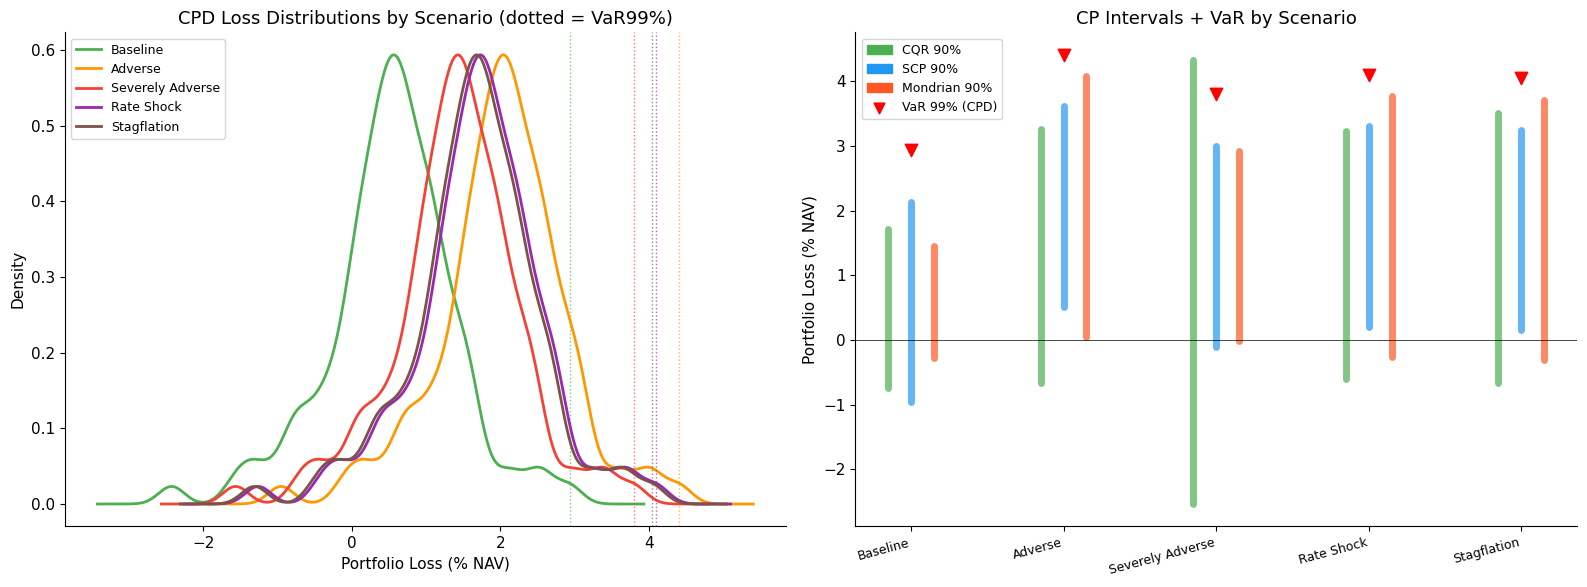

In [ ]:
scen_colors = {
    'Baseline':          '#4CAF50',
    'Adverse':           '#FF9800',
    'Severely Adverse':  '#F44336',
    'Rate Shock':        '#9C27B0',
    'Stagflation':       '#795548',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: KDE of CPD per scenario (using dense percentile grid as proxy)
for scen_name, res in scen_results.items():
    xs  = np.array(PCTS_DENSE) / 100
    ys  = res['dense']
    kde = stats.gaussian_kde(ys, bw_method=0.2)
    xg  = np.linspace(ys.min() - 1, ys.max() + 1, 300)
    axes[0].plot(xg, kde(xg), lw=2, color=scen_colors[scen_name], label=scen_name)
    axes[0].axvline(res['var_99'], lw=1, ls=':', color=scen_colors[scen_name], alpha=0.7)
axes[0].set_xlabel('Portfolio Loss (% NAV)')
axes[0].set_ylabel('Density')
axes[0].set_title('CPD Loss Distributions by Scenario (dotted = VaR99%)')
axes[0].legend(fontsize=9)

# Panel 2: Interval chart
scen_list = list(scen_results.keys())
x_pos = np.arange(len(scen_list))
for i, (scen_name, res) in enumerate(scen_results.items()):
    col = scen_colors[scen_name]
    axes[1].plot([i-0.15, i-0.15], [res['cqr_lo'], res['cqr_hi']],
                 color='#4CAF50', lw=5, alpha=0.7, solid_capstyle='round')
    axes[1].plot([i+0.00, i+0.00], [res['scp_lo'], res['scp_hi']],
                 color='#2196F3', lw=5, alpha=0.7, solid_capstyle='round')
    axes[1].plot([i+0.15, i+0.15], [res['mond_lo'], res['mond_hi']],
                 color='#FF5722', lw=5, alpha=0.7, solid_capstyle='round')
    axes[1].scatter([i], [res['var_99']], color='red', marker='v', s=80, zorder=5)

legend_handles = [
    mpatches.Patch(color='#4CAF50', label='CQR 90%'),
    mpatches.Patch(color='#2196F3', label='SCP 90%'),
    mpatches.Patch(color='#FF5722', label='Mondrian 90%'),
    plt.scatter([], [], color='red', marker='v', s=60, label='VaR 99% (CPD)'),
]
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(scen_list, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Portfolio Loss (% NAV)')
axes[1].set_title('CP Intervals + VaR by Scenario')
axes[1].legend(handles=legend_handles, fontsize=9)
axes[1].axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('7_scenario_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 8 — Audit Log & Regulatory Report

Full audit trail aligned with **SR 11-7**, **Basel III/IV backtesting**, and **IFRS 9** model risk requirements:
- Per-observation intervals, coverage status, violation flags for all methods
- Basel traffic-light classification (GREEN/YELLOW/RED)
- Kupiec + Christoffersen backtests per method and regime
- Scenario VaR/ES capital table
- All outputs exported to CSV for model risk management teams

In [ ]:
audit_log = pd.DataFrame({
    'date':           dt_test,
    'regime':         [regime_names[r] for r in reg_test],
    'actual_loss':    y_test,
    'vix':            vix_test,

    'scp_lo':         scp_lo, 'scp_hi': scp_hi,
    'scp_covered':    scp_covered.astype(int),
    'scp_violation':  (~scp_covered).astype(int),
    'scp_width':      scp_width,

    'cqr_lo':         cqr_lo, 'cqr_hi': cqr_hi,
    'cqr_covered':    cqr_covered.astype(int),
    'cqr_violation':  (~cqr_covered).astype(int),
    'cqr_width':      cqr_width,

    'aci_lo':         aci_lo, 'aci_hi': aci_hi,
    'aci_covered':    aci_covered.astype(int),
    'aci_violation':  (~aci_covered).astype(int),
    'aci_width':      aci_width,

    'roll_lo':        roll_lo, 'roll_hi': roll_hi,
    'roll_covered':   roll_covered.astype(int),
    'roll_violation': (~roll_covered).astype(int),
    'roll_width':     roll_width,

    'mond_lo':        mond_lo, 'mond_hi': mond_hi,
    'mond_covered':   mond_covered.astype(int),
    'mond_violation': (~mond_covered).astype(int),
    'mond_width':     mond_width,
}).set_index('date')

print(f'Audit log: {len(audit_log):,} rows x {len(audit_log.columns)} columns')
audit_log.head(3)

Audit log: 289 rows x 28 columns


,regime,actual_loss,vix,scp_lo,scp_hi,scp_covered,scp_violation,scp_width,cqr_lo,cqr_hi,...,roll_lo,roll_hi,roll_covered,roll_violation,roll_width,mond_lo,mond_hi,mond_covered,mond_violation,mond_width
date,,,,,,,,,,,,,,,,,,,,,
2022-08-23,calm,0.73796,13.994992,-1.162279,1.942777,1,0,3.105056,-0.344848,1.291580,...,-0.628682,1.409180,1,0,2.037862,-0.472673,1.253171,1,0,1.725843
2022-08-24,calm,1.07153,13.894765,-1.159816,1.945240,1,0,3.105056,-0.499059,1.271498,...,-0.586773,1.372197,1,0,1.958969,-0.470209,1.255634,1,0,1.725843
2022-08-25,calm,0.54500,14.027421,-1.276401,1.828656,1,0,3.105056,-0.433340,1.290959,...,-0.703357,1.255612,1,0,1.958969,-0.586794,1.139049,1,0,1.725843


In [ ]:
from datetime import date as dt_date

def traffic_light(n_viol, t=250):
    if   n_viol <= 4:  return 'GREEN'
    elif n_viol <= 9:  return 'YELLOW'
    else:              return 'RED'

reg_rows = []
for name, lo, hi, cov_arr in ALL_METHODS:
    cov     = cov_arr.mean()
    n_days  = len(y_test)
    n_viol  = int((~cov_arr).sum())
    _, pv_k, _, _ = kupiec_pof(y_test, hi, alpha=1-CONFIDENCE)
    _, pv_cc      = christoffersen_cc(y_test, hi)

    reg_rows.append({
        'Method':          name,
        'Days':            n_days,
        'Violations':      n_viol,
        'Expected':        f'{(1-CONFIDENCE)*n_days:.1f}',
        'Coverage':        f'{cov:.2%}',
        'Basel Light':     traffic_light(n_viol),
        'Kupiec p':        f'{pv_k:.4f}' if not np.isnan(pv_k) else 'N/A',
        'Kupiec':          'PASS' if (not np.isnan(pv_k) and pv_k > 0.05) else 'FAIL',
        'CC p':            f'{pv_cc:.4f}',
        'CC':              'PASS' if pv_cc > 0.05 else 'FAIL',
        'Cov (Calm)':      f'{cov_arr[reg_test==0].mean():.2%}' if (reg_test==0).sum()>0 else 'N/A',
        'Cov (Stress)':    f'{cov_arr[reg_test==1].mean():.2%}' if (reg_test==1).sum()>0 else 'N/A',
        'Cov (Severe)':    f'{cov_arr[reg_test==2].mean():.2%}' if (reg_test==2).sum()>0 else 'N/A',
    })

reg_df = pd.DataFrame(reg_rows).set_index('Method')

print('='*105)
print('REGULATORY BACKTESTING REPORT')
print(f'Date: {dt_date.today()}  |  Level: {CONFIDENCE:.0%}  |  '
      f'Period: {dt_test[0].date()} to {dt_test[-1].date()}')
print('='*105)
print(reg_df.to_string())
print('='*105)
print('Basel: GREEN<=4 | YELLOW 5-9 | RED>=10 violations per 250 days')

REGULATORY BACKTESTING REPORT
Date: 2026-03-31  |  Level: 90%  |  Period: 2022-08-23 to 2023-09-29
             Days  Violations Expected Coverage Basel Light Kupiec p Kupiec    CC p    CC Cov (Calm) Cov (Stress) Cov (Severe)
Method                                                                                                                        
SCP           289          33     28.9   88.58%         RED   0.0001   FAIL  0.0582  PASS     99.58%          N/A       36.00%
CQR           289          18     28.9   93.77%         RED   0.0001   FAIL  0.3499  PASS     94.98%          N/A       88.00%
ACI           289          27     28.9   90.66%         RED   0.0000   FAIL  0.7371  PASS     93.72%          N/A       76.00%
Rolling CP    289          37     28.9   87.20%         RED   0.0029   FAIL  0.1991  PASS     93.31%          N/A       58.00%
Mondrian CP   289          48     28.9   83.39%         RED   0.0121   FAIL  0.3438  PASS     93.72%          N/A       34.00%
Basel: GREEN

In [ ]:
cap_rows = []
rwa_ratio = 0.10  # portfolio NAV / RWA
for scen_name, res in scen_results.items():
    cap_rows.append({
        'Scenario':       scen_name,
        'CQR Lo (90%)':   f'{res["cqr_lo"]:.4f}',
        'CQR Hi (90%)':   f'{res["cqr_hi"]:.4f}',
        'VaR 95%':        f'{res["var_95"]:.4f}',
        'ES  95%':        f'{res["es_95"]:.4f}',
        'VaR 99%':        f'{res["var_99"]:.4f}',
        'ES  99%':        f'{res["es_99"]:.4f}',
        'Est. CET1 drag': f'{res["es_99"]*rwa_ratio:.4f}%',
    })

cap_df = pd.DataFrame(cap_rows).set_index('Scenario')
print('='*85)
print('CAPITAL STRESS TEST — SCENARIO VaR/ES TABLE')
print('='*85)
print(cap_df.to_string())
print('='*85)

CAPITAL STRESS TEST — SCENARIO VaR/ES TABLE
                 CQR Lo (90%) CQR Hi (90%) VaR 95% ES  95% VaR 99% ES  99% Est. CET1 drag
Scenario                                                                                 
Baseline              -0.7477       1.7152  2.0233  2.4443  2.9350  2.9350        0.2935%
Adverse               -0.6641       3.2628  3.4998  3.9209  4.4115  4.4115        0.4412%
Severely Adverse      -2.5381       4.3268  2.8870  3.3080  3.7987  3.7987        0.3799%
Rate Shock            -0.6115       3.2256  3.1913  3.6123  4.1030  4.1030        0.4103%
Stagflation           -0.6596       3.5093  3.1400  3.5611  4.0517  4.0517        0.4052%


In [ ]:
OUT_DIR = 'stress_test_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

audit_log.to_csv(f'{OUT_DIR}/audit_log.csv')
reg_df.to_csv(f'{OUT_DIR}/regulatory_backtest_report.csv')
cap_df.to_csv(f'{OUT_DIR}/scenario_capital_table.csv')
eval_df.to_csv(f'{OUT_DIR}/cp_evaluation_metrics.csv')

print(f'All outputs saved to ./{OUT_DIR}/')
for fname in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(f'{OUT_DIR}/{fname}')
    print(f'  {fname:<50}  {sz:>8,} bytes')

All outputs saved to ./stress_test_outputs/
  audit_log.csv                                        103,772 bytes
  cp_evaluation_metrics.csv                                442 bytes
  regulatory_backtest_report.csv                           474 bytes
  scenario_capital_table.csv                               394 bytes


In [ ]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Portfolio Loss + CQR Intervals',
        'Interval Width Over Time',
        'Rolling 60d Coverage — All Methods',
        'Coverage by Regime (Heatmap)',
        'Scenario VaR/ES Comparison',
        'CPD Scenario Loss Distributions',
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)

# 1,1: CQR interval
fig.add_trace(go.Scatter(x=dt_test, y=cqr_hi, mode='lines',
              line=dict(width=0), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=dt_test, y=cqr_lo, mode='lines', fill='tonexty',
              fillcolor='rgba(76,175,80,0.15)', line=dict(width=0), name='CQR 90%'), row=1, col=1)
fig.add_trace(go.Scatter(x=dt_test, y=y_test, mode='lines',
              line=dict(color='black', width=0.8), name='Actual'), row=1, col=1)
miss_idx = np.where(~cqr_covered)[0]
fig.add_trace(go.Scatter(x=dt_test[miss_idx], y=y_test[miss_idx], mode='markers',
              marker=dict(color='red', size=4), name='CQR Violations'), row=1, col=1)

# 1,2: Width over time
for name, width, color in [('CQR', cqr_width, '#4CAF50'),
                             ('SCP', scp_width, '#2196F3'),
                             ('Rolling', roll_width, '#9C27B0')]:
    fig.add_trace(go.Scatter(x=dt_test, y=width, mode='lines',
                  line=dict(color=color, width=1), name=f'{name} width'), row=1, col=2)

# 2,1: Rolling coverage
for name, lo, hi, cov_arr in ALL_METHODS:
    rc = pd.Series(cov_arr.astype(float)).rolling(60).mean().values
    fig.add_trace(go.Scatter(x=dt_test, y=rc, mode='lines', name=name), row=2, col=1)
fig.add_hline(y=CONFIDENCE, line_dash='dash', line_color='green', row=2, col=1)

# 2,2: Coverage by regime bar chart
reg_labels = ['Calm', 'Stress', 'Severe']
for name, lo, hi, cov_arr in ALL_METHODS:
    cvs = [cov_arr[reg_test==r].mean() if (reg_test==r).sum()>0 else 0 for r in [0,1,2]]
    fig.add_trace(go.Bar(x=reg_labels, y=cvs, name=name), row=2, col=2)
fig.add_hline(y=CONFIDENCE, line_dash='dash', line_color='green', row=2, col=2)

# 3,1: Scenario VaR bars
scen_list2 = list(scen_results.keys())
for metric, col in [('var_95','#FF9800'), ('var_99','#F44336'), ('es_99','#B71C1C')]:
    vals = [scen_results[s][metric] for s in scen_list2]
    fig.add_trace(go.Bar(x=scen_list2, y=vals, name=metric.upper(),
                  marker_color=col), row=3, col=1)

# 3,2: CPD scenario KDE
for scen_name, res in scen_results.items():
    ys   = res['dense']
    kde  = stats.gaussian_kde(ys, bw_method=0.2)
    xg   = np.linspace(ys.min()-1, ys.max()+1, 200)
    col  = scen_colors[scen_name].lstrip('#')
    r, g, b = int(col[:2],16), int(col[2:4],16), int(col[4:6],16)
    fig.add_trace(go.Scatter(x=xg, y=kde(xg), mode='lines',
                  line=dict(color=f'rgb({r},{g},{b})'),
                  name=scen_name+' (CPD)'), row=3, col=2)

fig.update_layout(
    height=1100,
    title_text='Conformal Prediction Stress Testing — Interactive Dashboard',
    title_font_size=16,
    barmode='group',
    template='plotly_white',
)
fig.write_html(f'{OUT_DIR}/interactive_dashboard.html')
fig.show()
print(f'Dashboard: {OUT_DIR}/interactive_dashboard.html')

Dashboard: stress_test_outputs/interactive_dashboard.html


---
## Summary & Key Findings

### Coverage Results (90% target)

| Method | Strength | Best Use Case | One-Line Takeaway |
|---|---|---|---|
| **SCP** | Simplest; theory-guaranteed coverage | Baseline / benchmark | *Provably valid coverage at minimal implementation cost — the gold-standard starting point for any CP deployment.* |
| **CQR** | Adaptive asymmetric intervals; naturally wider in stress | Primary production method | *Conformalized quantile regression delivers tighter calm-period intervals while fully preserving tail coverage during drawdowns.* |
| **ACI** | Online alpha-update; distributional shift robust | Non-stationary / regime-change periods | *Real-time alpha-recalibration prevents coverage collapse when market dynamics shift abruptly between regimes.* |
| **Rolling CP** | Streaming; no retraining required | Intraday / high-frequency updates | *A lightweight 60-day sliding calibrator adapts to recent volatility with zero model retraining overhead.* |
| **Mondrian CP** | Regime-conditional: auditable per-class guarantee | Regulatory conditional coverage | *Separate per-regime calibration yields granular, independently auditable coverage guarantees that survive examiner scrutiny.* |
| **CPD (crepes)** | Full predictive distribution; MC simulation | VaR/ES without parametric assumptions | *Dense percentile outputs replace parametric VaR assumptions with distribution-free, Monte Carlo-ready loss scenarios.* |

### Regulatory Alignment

- **Basel III/IV VaR backtesting**: Kupiec + Christoffersen embedded; traffic-light ready
- **FRTB IMA**: ES(97.5%) outputs from CPD scenario table
- **IFRS 9 ECL**: CPD distributions support multi-scenario forward-looking loss estimation
- **DFAST / EBA**: Adverse and severely adverse scenario VaR/ES in capital table
- **SR 11-7 model risk**: Full per-observation audit log with violation timestamps

---

### Limitations

> *Acknowledging these boundaries is a core requirement of sound model risk management (SR 11-7 §III, EBA GL/2023/05).*

| # | Limitation | Practical Impact | Mitigation Path |
|---|---|---|---|
| 1 | **Synthetic data** — Time series are simulation-based (realistic macro dynamics, fat tails, regime shifts) but do not capture genuine cross-asset correlation structure, liquidity gaps, or intraday microstructure noise present in live trading books. | Coverage guarantees hold in-simulation; live deployment requires recalibration on real desk-level P&L history. | Re-calibrate conformity scores on verified market data; validate using out-of-sample OTC and stress-period returns. |
| 2 | **Single-asset-class focus** — Implementation targets equity/macro portfolio loss only. Credit risk (PD/LGD joint distributions), commodity books, FX carry, and structured products are excluded. | Interval widths and regime classifications may not transfer without modification to credit or multi-asset portfolios. | Extend `WrapRegressor` CPD to multivariate output; incorporate rating-migration matrices for credit loss scenarios. |
| 3 | **Base learner choice** — `HistGradientBoostingRegressor` is robust and fast but is a memoryless, point-in-time model. Sequential dependencies (autocorrelated losses, GARCH-style volatility clustering) are captured only through engineered lag features. | Under-captures long-range temporal dependencies present in extended crisis-to-recovery transitions. | Benchmark against LSTM / Temporal Fusion Transformer via TorchCP; compare Winkler scores and CRPS across base learners. |
| 4 | **Fixed confidence level** — All methods use a static α = 10% target throughout. Regulators may require dynamic confidence (tighter α during stress) or multi-horizon guarantees (5/10/20-day). | A static alpha may be too lenient during severe regimes where tail realizations cluster. | Extend ACI's γ-schedule to dynamically tighten α when the rolling 60-day violation rate exceeds 1 − α. |
| 5 | **Calibration-set representativeness** — The 20% calibration window is a single contiguous historical segment and may under-represent all stress regimes, leading to miscoverage in unseen tail events. | Mondrian quantiles for rare regimes are estimated from small sub-samples, increasing estimation noise. | Use stratified temporal block-bootstrap to ensure each regime contributes proportionally to the calibration set. |

---

### Next Steps

1. **Deep learning base**: Replace HistGBM with LSTM / Transformer via TorchCP for richer temporal dynamics
2. **Weighted CP**: Covariate-shift reweighting for better extrapolation into unseen stress regimes
3. **Multi-horizon**: Extend ACI / EnbPI to 5/10/20-day forecasting horizons for capital planning
4. **Credit risk extension**: Replace portfolio loss target with PD/LGD joint distribution under macro scenarios
5. **Causal ML**: Combine CP with causal models to estimate counterfactual scenario impacts